Task1: Learning the map from the particle features, geom features of the simulation and conditional channeling to the velocity of particles and gradient of velocity of particles. This bypasses the need for heavy computation involving P2P interaction solved using FMM. The prediction from the trained model is then used in a normal time marching integrator in FLOWUnsteady to evolve the states of the particle.

Task1 requires a GNO as the map is from a Lagrangian field to another, which becomes a graph problem - a domain under representation learning, for effective feature selection in graphs.

In [1]:
from pathlib import Path
import json
import time
import random
import inspect

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader

Snippet saves the best model in .pt format in the result folder.

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

current_directory = Path.cwd().resolve()
if (current_directory / 'final-2' / 'processed_data_task1').exists():
    project_folder = current_directory / 'final-2'
elif current_directory.name == 'notebooks' and (current_directory.parent / 'processed_data_task1').exists():
    project_folder = current_directory.parent
else:
    project_folder = current_directory

dataset_path = project_folder / 'processed_data_task1' / 'particle_ugradu_dataset.npz'
results_folder = project_folder / 'result' / 'task1'
results_folder.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Project folder:', project_folder)
print('Dataset path  :', dataset_path)
print('Results folder:', results_folder)
print('Device        :', device)
if device.type == 'cuda':
    print('GPU           :', torch.cuda.get_device_name(0))

if not dataset_path.exists():
    raise FileNotFoundError('Missing particle_ugradu_dataset.npz. Run final-2/preprocess_data.py first.')


Project folder: /home/dysco/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/final-2
Dataset path  : /home/dysco/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/final-2/processed_data_task1/particle_ugradu_dataset.npz
Results folder: /home/dysco/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/final-2/result/task1
Device        : cpu


features and targets from the processed particle frames - raw and normalized arrays

Q: Why should normalization be computed only from the training split of data

Q: Does the geometric encoding really matter? The positions of the particles are a direct channel and they are not predicted. Hence, why will geometry of airfoil matter for this case of prediction of ugradu

Q: The n_particles associated with each frame is the number of particles shed extra during that period, instead shouldn't it be the total number of particles currently in the frame, and why can't that be a feature?


The split is preprocess_data.py is still according to what was written in the Sheets, and has not been changed to radom sampling of train-validate amongst the entire dataset. Fix it in preprocess_data.py

In [3]:
dataset_file = np.load(dataset_path, allow_pickle=True)

# These are all channels physically stored in the preprocessed .npz file.
# The notebook can select a subset of them for the model without rebuilding the dataset.
raw_feature_names_from_file = [str(name) for name in dataset_file['feature_names'].tolist()]
target_names = [str(name) for name in dataset_file['target_names'].tolist()]
frame_contexts = list(dataset_file['frame_contexts'])
frame_ranges = list(dataset_file['frame_ranges'])

# ------------------------------------------------------------
# Model input-channel controls
# ------------------------------------------------------------
# geom_body_near was found to be weak/non-informative for the current dataset, so it is always removed.
# The remaining geometry channels are kept: geom_dist, geom_nx, geom_ny, geom_nz.
permanently_removed_input_features = [
    'geom_body_near',
]

# Freestream x/z are deterministic functions of AoA when freestream magnitude is fixed.
# Keep this False for the cleaner experiment. Set True only if you want to test whether redundant channels help.
use_freestream_vector_features_as_model_input = False
freestream_vector_feature_names = [
    'freestream_x',
    'freestream_z',
]

removed_by_toggle = [] if use_freestream_vector_features_as_model_input else freestream_vector_feature_names
removed_input_feature_names = sorted(set(permanently_removed_input_features + removed_by_toggle))

# active_input_feature_indices maps the stored .npz columns to the columns actually sent into the model.
active_input_feature_indices = [
    i for i, name in enumerate(raw_feature_names_from_file)
    if name not in removed_input_feature_names
]

# feature_names is intentionally the model-visible feature list, not necessarily every stored column.
feature_names = [raw_feature_names_from_file[i] for i in active_input_feature_indices]
removed_input_features = [
    name for name in raw_feature_names_from_file
    if name not in feature_names
]

print('All stored input features:')
print(raw_feature_names_from_file)
print()
print('Model input features after channel selection:')
print(feature_names)
print()
print('Removed input features:')
print(removed_input_features if removed_input_features else 'none')
print()
print('Freestream vector channels used:', use_freestream_vector_features_as_model_input)
print('Output target names:')
print(target_names)



All stored input features:
['x', 'y', 'z', 'Gamma_x', 'Gamma_y', 'Gamma_z', 'sigma', 'geom_dist', 'geom_nx', 'geom_ny', 'geom_nz', 'geom_body_near', 'angle_of_attack', 'freestream_x', 'freestream_z', 'phase']

Model input features after channel selection:
['x', 'y', 'z', 'Gamma_x', 'Gamma_y', 'Gamma_z', 'sigma', 'geom_dist', 'geom_nx', 'geom_ny', 'geom_nz', 'angle_of_attack', 'phase']

Removed input features:
['geom_body_near', 'freestream_x', 'freestream_z']

Freestream vector channels used: False
Output target names:
['velocity_x', 'velocity_y', 'velocity_z', 'gradUx_x', 'gradUx_y', 'gradUx_z', 'gradUy_x', 'gradUy_y', 'gradUy_z', 'gradUz_x', 'gradUz_y', 'gradUz_z']


Q: How should the normalization be performed? Here, it is done framewises.
Why can't it be for one dataset entirely, there is a range of say Gamma, and you normalize the values in each frame according to the global values?

Q: Is this same distribution function correct? Shouldn't it be done in preprocess file?

Validation samples are selected periodically from the temporal sequence of each simulation case

In [4]:
if 'inputs_by_frame_norm' not in dataset_file or 'targets_by_frame_norm' not in dataset_file:
    raise RuntimeError('This notebook expects frame-wise arrays from preprocess_data.py.')

# Slice input arrays to the active model feature set. Targets are unchanged.
# This removes non-informative/redundant columns selected in the input-channel controls above.
inputs_by_frame_normalized = [
    np.asarray(x, dtype=np.float32)[:, active_input_feature_indices]
    for x in dataset_file['inputs_by_frame_norm'].tolist()
]
targets_by_frame_normalized = [np.asarray(y, dtype=np.float32) for y in dataset_file['targets_by_frame_norm'].tolist()]
inputs_by_frame_raw = [
    np.asarray(x, dtype=np.float32)[:, active_input_feature_indices]
    for x in dataset_file['inputs_by_frame'].tolist()
]
targets_by_frame_raw = [np.asarray(y, dtype=np.float32) for y in dataset_file['targets_by_frame'].tolist()]

training_frame_ids = dataset_file['train_frame_ids'].astype(np.int64)

# Function definition for same distribution sampling for the split.
def make_same_distribution_validation_split(train_ids, stride=5, offset=2, min_per_case=8):
    by_case = {}
    for frame_id in np.asarray(train_ids, dtype=np.int64):
        case = str(frame_ranges[int(frame_id)][0])
        by_case.setdefault(case, []).append(int(frame_id))

    train_out = []
    validation_out = []
    for case, ids in sorted(by_case.items()):
        ids_sorted = sorted(ids, key=lambda j: int(str(frame_ranges[int(j)][1])))
        if len(ids_sorted) <= 1:
            train_out.extend(ids_sorted)
            continue

        stride_value = max(int(stride), 2)
        offset_value = min(max(int(offset), 0), stride_value - 1)
        validation_ids = ids_sorted[offset_value::stride_value]

        minimum_validation = min(max(int(min_per_case), 1), max(len(ids_sorted) - 1, 1))
        if len(validation_ids) < minimum_validation:
            existing = set(validation_ids)
            validation_ids.extend([j for j in ids_sorted if j not in existing][:minimum_validation - len(validation_ids)])

        validation_set = set(validation_ids)
        case_train_ids = [j for j in ids_sorted if j not in validation_set]
        if not case_train_ids:
            case_train_ids = ids_sorted[:-1]
            validation_ids = ids_sorted[-1:]

        train_out.extend(case_train_ids)
        validation_out.extend(validation_ids)

    return np.asarray(sorted(train_out), dtype=np.int64), np.asarray(sorted(validation_out), dtype=np.int64)



In [5]:
if 'val_id_frame_ids' in dataset_file.files and len(dataset_file['val_id_frame_ids']) > 0:
    validation_frame_ids = dataset_file['val_id_frame_ids'].astype(np.int64)
else:
    print('[warn] val_id_frame_ids is missing/empty in the .npz file.')
    print('[warn] Building same-distribution validation split in-memory from train_frame_ids.')
    print('[warn] For final clean experiments, rerun final-2/preprocess_data.py so this split is saved in the dataset.')
    training_frame_ids, validation_frame_ids = make_same_distribution_validation_split(
        training_frame_ids, stride=5, offset=2, min_per_case=8
    )

validation_angle_frame_ids = dataset_file['validation_angle_frame_ids'].astype(np.int64) if 'validation_angle_frame_ids' in dataset_file.files else dataset_file['val_frame_ids'].astype(np.int64) if 'val_frame_ids' in dataset_file.files else np.array([], dtype=np.int64)
testing_frame_ids = dataset_file['test_frame_ids'].astype(np.int64) if 'test_frame_ids' in dataset_file.files else np.array([], dtype=np.int64)


def frame_context_as_dict(frame_id):
    # np.savez stores dictionaries as object arrays; this helper converts them back safely.
    context = frame_contexts[int(frame_id)]
    if isinstance(context, dict):
        return context
    if hasattr(context, 'item'):
        maybe_dict = context.item()
        if isinstance(maybe_dict, dict):
            return maybe_dict
    return dict(context)



# Reproducible random temporal sampling helper.
# Use this for diagnostics/evaluation subsets so early transient frames do not dominate.
def sample_frame_ids(frame_ids, maximum_frames=None, seed_offset=0, sort_after_sampling=False):
    frame_ids = np.asarray(frame_ids, dtype=np.int64)
    if maximum_frames is None or len(frame_ids) <= int(maximum_frames):
        chosen = frame_ids.copy()
    else:
        rng = np.random.default_rng(SEED + int(seed_offset))
        chosen = rng.choice(frame_ids, size=int(maximum_frames), replace=False)
    if sort_after_sampling:
        chosen = np.asarray(sorted(chosen, key=lambda f: int(float(frame_context_as_dict(int(f)).get('frame', frame_ranges[int(f)][1])))), dtype=np.int64)
    return chosen


def sample_dataset_indices(dataset, maximum_items=None, seed_offset=0):
    indices = np.arange(len(dataset), dtype=np.int64)
    if maximum_items is None or len(indices) <= int(maximum_items):
        return indices
    rng = np.random.default_rng(SEED + int(seed_offset))
    return rng.choice(indices, size=int(maximum_items), replace=False)


def test_frame_ids_for_role(role_name, saved_key, aoa_fallback=None):
    # Prefer explicit preprocessing keys. Fallback keeps older preprocessed files readable.
    if saved_key in dataset_file.files:
        return dataset_file[saved_key].astype(np.int64)
    selected = []
    for frame_id in testing_frame_ids:
        context = frame_context_as_dict(int(frame_id))
        if str(context.get('test_role', '')) == role_name:
            selected.append(int(frame_id))
            continue
        if aoa_fallback is not None and int(round(float(context.get('aoa_deg', -999)))) == int(aoa_fallback):
            selected.append(int(frame_id))
    return np.asarray(selected, dtype=np.int64)

# Testing split - sr, unseen
testing_normal_frame_ids = test_frame_ids_for_role('testing_normal', 'test_normal_frame_ids', aoa_fallback=27)
testing_super_resolution_frame_ids = test_frame_ids_for_role(
    'testing_super_resolution', 'test_super_resolution_frame_ids', aoa_fallback=19
)
testing_unseen_angle_frame_ids = test_frame_ids_for_role('testing_unseen_angle', 'test_unseen_angle_frame_ids', aoa_fallback=32)

# ------------------------------------------------------------
# Remove frames whose complete target vector is zero.
# These are usually startup frame 000000 cases before the particle field has nonzero u/gradU.
# Keeping them makes relative error undefined and gives the optimizer a physically uninformative sample.
# ------------------------------------------------------------
minimum_target_norm_to_keep = 1.0e-12
removed_zero_target_frames = {}


def target_norm_for_frame(frame_id):
    target = targets_by_frame_raw[int(frame_id)]
    return float(np.linalg.norm(target.reshape(-1)))


def filter_zero_target_frames(frame_ids, split_name):
    kept = []
    removed = []
    for frame_id in np.asarray(frame_ids, dtype=np.int64):
        norm_value = target_norm_for_frame(int(frame_id))
        if norm_value > minimum_target_norm_to_keep:
            kept.append(int(frame_id))
        else:
            context = frame_context_as_dict(int(frame_id))
            removed.append({
                'frame_id': int(frame_id),
                'case': str(context.get('case', context.get('case_name', 'unknown'))),
                'frame': str(context.get('frame', context.get('fr', 'unknown'))),
                'target_norm': norm_value,
            })

    removed_zero_target_frames[split_name] = removed
    if removed:
        print(f'[filter] {split_name}: removed {len(removed)} zero-target frames; examples={removed[:3]}')
    else:
        print(f'[filter] {split_name}: no zero-target frames removed')
    return np.asarray(kept, dtype=np.int64)


training_frame_ids = filter_zero_target_frames(training_frame_ids, 'training')
validation_frame_ids = filter_zero_target_frames(validation_frame_ids, 'validation')
validation_angle_frame_ids = filter_zero_target_frames(validation_angle_frame_ids, 'validation_angle')
testing_frame_ids = filter_zero_target_frames(testing_frame_ids, 'testing_all')
testing_normal_frame_ids = filter_zero_target_frames(testing_normal_frame_ids, 'testing_normal')
testing_super_resolution_frame_ids = filter_zero_target_frames(testing_super_resolution_frame_ids, 'testing_super_resolution')
testing_unseen_angle_frame_ids = filter_zero_target_frames(testing_unseen_angle_frame_ids, 'testing_unseen_angle')

has_validation_data = len(validation_frame_ids) > 0
has_testing_data = len(testing_frame_ids) > 0

output_mean = torch.tensor(dataset_file['out_mean'].astype(np.float32), device=device)
output_standard_deviation = torch.tensor(dataset_file['out_std'].astype(np.float32), device=device)

input_dimension = int(inputs_by_frame_normalized[0].shape[1])
output_dimension = int(targets_by_frame_normalized[0].shape[1])



[filter] training: removed 11 zero-target frames; examples=[{'frame_id': 0, 'case': '10deg_static_airfoil_10u_1p', 'frame': '000000', 'target_norm': 0.0}, {'frame_id': 402, 'case': '12deg_static_airfoil_10u_1p', 'frame': '000000', 'target_norm': 0.0}, {'frame_id': 603, 'case': '14deg_static_airfoil_10u_1p', 'frame': '000000', 'target_norm': 0.0}]
[filter] validation: no zero-target frames removed
[filter] validation_angle: removed 4 zero-target frames; examples=[{'frame_id': 201, 'case': '11deg_static_airfoil_10u_1p', 'frame': '000000', 'target_norm': 0.0}, {'frame_id': 804, 'case': '15deg_static_airfoil_10u_1p', 'frame': '000000', 'target_norm': 0.0}, {'frame_id': 1809, 'case': '21deg_static_airfoil_10u_1p', 'frame': '000000', 'target_norm': 0.0}]
[filter] testing_all: removed 3 zero-target frames; examples=[{'frame_id': 1407, 'case': '19deg_static_airfoil_10u_2p', 'frame': '000000', 'target_norm': 0.0}, {'frame_id': 2814, 'case': '27deg_static_airfoil_10u_1p', 'frame': '000000', 'tar

In [6]:
print('Number of frames      :', len(inputs_by_frame_normalized))
print('Input feature count   :', input_dimension)
print('Output target count   :', output_dimension)
print('Training frames       :', len(training_frame_ids))
print('Validation frames     :', len(validation_frame_ids), '(same-distribution frames from training cases)')
print('Held-out angle validation frames:', len(validation_angle_frame_ids))
print('Testing frames        :', len(testing_frame_ids))
print('  normal test frames  :', len(testing_normal_frame_ids))
print('  super-res test frames:', len(testing_super_resolution_frame_ids))
print('  unseen-angle frames :', len(testing_unseen_angle_frame_ids))
print('Input feature names   :', feature_names)
print('Freestream vector channels used:', use_freestream_vector_features_as_model_input)
print('Removed input features:', removed_input_features if removed_input_features else 'none')
print('Output target names   :', target_names)
if not has_validation_data:
    print('[info] No validation frames yet. The notebook will skip validation plots/metrics until those cases exist.')
if not has_testing_data:
    print('[info] No testing frames yet. The notebook will skip testing plots/metrics until those cases exist.')




Number of frames      : 3618
Input feature count   : 13
Output target count   : 12
Training frames       : 1760
Validation frames     : 440 (same-distribution frames from training cases)
Held-out angle validation frames: 800
Testing frames        : 600
  normal test frames  : 200
  super-res test frames: 200
  unseen-angle frames : 200
Input feature names   : ['x', 'y', 'z', 'Gamma_x', 'Gamma_y', 'Gamma_z', 'sigma', 'geom_dist', 'geom_nx', 'geom_ny', 'geom_nz', 'angle_of_attack', 'phase']
Freestream vector channels used: False
Removed input features: ['geom_body_near', 'freestream_x', 'freestream_z']
Output target names   : ['velocity_x', 'velocity_y', 'velocity_z', 'gradUx_x', 'gradUx_y', 'gradUx_z', 'gradUy_x', 'gradUy_y', 'gradUy_z', 'gradUz_x', 'gradUz_y', 'gradUz_z']


In [7]:
# Silent failures before model training: missing values, wrong shapes, and split leakage.

def check_frame_arrays(frame_ids, split_name, maximum_frames_to_check=50):
    if len(frame_ids) == 0:
        print(f'[{split_name}] no frames available yet; skipping array checks.')
        return

    for frame_id in sample_frame_ids(frame_ids, maximum_frames_to_check, seed_offset=11):
        input_raw = inputs_by_frame_raw[int(frame_id)]
        target_raw = targets_by_frame_raw[int(frame_id)]
        input_normalized = inputs_by_frame_normalized[int(frame_id)]
        target_normalized = targets_by_frame_normalized[int(frame_id)]

        if input_raw.ndim != 2 or input_raw.shape[1] != input_dimension:
            raise RuntimeError(f'{split_name} frame {frame_id}: bad input shape {input_raw.shape}')
        if target_raw.ndim != 2 or target_raw.shape[1] != output_dimension:
            raise RuntimeError(f'{split_name} frame {frame_id}: bad target shape {target_raw.shape}')
        if input_raw.shape[0] != target_raw.shape[0]:
            raise RuntimeError(f'{split_name} frame {frame_id}: input/target particle count mismatch')
        if not np.isfinite(input_raw).all() or not np.isfinite(input_normalized).all():
            raise RuntimeError(f'{split_name} frame {frame_id}: NaN or inf in input')
        if not np.isfinite(target_raw).all() or not np.isfinite(target_normalized).all():
            raise RuntimeError(f'{split_name} frame {frame_id}: NaN or inf in target')

    print(f'[{split_name}] checked {min(len(frame_ids), maximum_frames_to_check)} randomly sampled frames successfully.')


def cases_for_frame_ids(frame_ids):
    cases = []
    for frame_id in np.asarray(frame_ids, dtype=np.int64):
        cases.append(str(frame_ranges[int(frame_id)][0]))
    return set(cases)

check_frame_arrays(training_frame_ids, 'training')
check_frame_arrays(validation_frame_ids, 'validation')
check_frame_arrays(testing_frame_ids, 'testing')

training_cases = cases_for_frame_ids(training_frame_ids)
validation_cases = cases_for_frame_ids(validation_frame_ids)
testing_cases = cases_for_frame_ids(testing_frame_ids)

print('Training cases  :', sorted(training_cases))
print('Validation cases:', sorted(validation_cases))
print('Testing cases   :', sorted(testing_cases))

# Same-distribution validation is intentionally drawn from the training cases.
# It is used for tuning/early stopping, not for final generalization claims.
shared_train_validation_cases = training_cases & validation_cases
print('Shared train/validation cases:', sorted(shared_train_validation_cases))

# Testing must remain case-disjoint from anything used for fitting or tuning.
if training_cases & testing_cases:
    raise RuntimeError('Case leakage: at least one case appears in both training and testing.')
if validation_cases & testing_cases:
    raise RuntimeError('Case leakage: at least one case appears in both validation and testing.')


[training] checked 50 randomly sampled frames successfully.
[validation] checked 50 randomly sampled frames successfully.
[testing] checked 50 randomly sampled frames successfully.
Training cases  : ['10deg_static_airfoil_10u_1p', '12deg_static_airfoil_10u_1p', '14deg_static_airfoil_10u_1p', '16deg_static_airfoil_10u_1p', '18deg_static_airfoil_10u_1p', '20deg_static_airfoil_10u_1p', '22deg_static_airfoil_10u_1p', '24deg_static_airfoil_10u_1p', '26deg_static_airfoil_10u_1p', '28deg_static_airfoil_10u_1p', '30deg_static_airfoil_10u_1p']
Validation cases: ['10deg_static_airfoil_10u_1p', '12deg_static_airfoil_10u_1p', '14deg_static_airfoil_10u_1p', '16deg_static_airfoil_10u_1p', '18deg_static_airfoil_10u_1p', '20deg_static_airfoil_10u_1p', '22deg_static_airfoil_10u_1p', '24deg_static_airfoil_10u_1p', '26deg_static_airfoil_10u_1p', '28deg_static_airfoil_10u_1p', '30deg_static_airfoil_10u_1p']
Testing cases   : ['19deg_static_airfoil_10u_2p', '27deg_static_airfoil_10u_1p', '32deg_static_airf

In [8]:
# validation/testing target magnitudes live in the same range as training.

def sample_target_magnitudes(frame_ids, maximum_frames=40, maximum_particles_per_frame=1000000):
    if len(frame_ids) == 0:
        return None

    chosen_frame_ids = sample_frame_ids(frame_ids, maximum_frames, seed_offset=23)
    velocity_magnitudes = []
    gradient_magnitudes = []

    for frame_id in chosen_frame_ids:
        target = targets_by_frame_raw[int(frame_id)]
        if target.shape[0] > maximum_particles_per_frame:
            picked = np.random.default_rng(SEED + int(frame_id)).choice(
                target.shape[0], size=maximum_particles_per_frame, replace=False
            )
            target = target[picked]

        velocity_magnitudes.append(np.linalg.norm(target[:, :3], axis=1))
        gradient_magnitudes.append(np.linalg.norm(target[:, 3:], axis=1))

    velocity_magnitudes = np.concatenate(velocity_magnitudes)
    gradient_magnitudes = np.concatenate(gradient_magnitudes)
    return {
        'mean_velocity': float(np.mean(velocity_magnitudes)),
        'median_velocity': float(np.median(velocity_magnitudes)),
        'mean_velocity_gradient': float(np.mean(gradient_magnitudes)),
        'median_velocity_gradient': float(np.median(gradient_magnitudes)),
        'velocity_95_percentile': float(np.quantile(velocity_magnitudes, 0.95)),
        'velocity_gradient_95_percentile': float(np.quantile(gradient_magnitudes, 0.95)),
    }

split_statistics = {
    'training': sample_target_magnitudes(training_frame_ids),
    'validation': sample_target_magnitudes(validation_frame_ids),
    'testing': sample_target_magnitudes(testing_frame_ids),
}

print(json.dumps(split_statistics, indent=2))

training_velocity_mean = split_statistics['training']['mean_velocity']
for split_name in ['validation', 'testing']:
    if split_statistics[split_name] is None:
        continue
    ratio = split_statistics[split_name]['mean_velocity'] / max(training_velocity_mean, 1e-12)
    print(f'{split_name} mean |u| / training mean |u| = {ratio:.3f}')

print('')
print('Interpretation: target normalization helps optimization, but it cannot fully remove a physics distribution shift.')
print('If testing magnitudes are very different from training magnitudes, add training cases that cover that range.')


{
  "training": {
    "mean_velocity": 1.3095701932907104,
    "median_velocity": 1.1474814414978027,
    "mean_velocity_gradient": 17.008493423461914,
    "median_velocity_gradient": 10.295616149902344,
    "velocity_95_percentile": 3.0210039615631104,
    "velocity_gradient_95_percentile": 52.08707046508789
  },
  "validation": {
    "mean_velocity": 1.2905082702636719,
    "median_velocity": 1.0954464673995972,
    "mean_velocity_gradient": 16.737274169921875,
    "median_velocity_gradient": 10.383541107177734,
    "velocity_95_percentile": 3.0223755836486816,
    "velocity_gradient_95_percentile": 51.04860305786133
  },
  "testing": {
    "mean_velocity": 1.8192851543426514,
    "median_velocity": 1.5766937732696533,
    "mean_velocity_gradient": 30.366539001464844,
    "median_velocity_gradient": 14.965601921081543,
    "velocity_95_percentile": 4.026220321655273,
    "velocity_gradient_95_percentile": 113.04069519042969
  }
}
validation mean |u| / training mean |u| = 0.985
testin

Normalization is with respect to train data alone.

In [9]:
# Input normalization statistics are stored for all preprocessed columns.
# They may be saved as shape (1, channels), so flatten to a channel vector before slicing.
input_mean_all_channels = dataset_file['in_mean'].astype(np.float32).reshape(-1)
input_standard_deviation_all_channels = dataset_file['in_std'].astype(np.float32).reshape(-1)
input_mean = input_mean_all_channels[active_input_feature_indices]
input_standard_deviation = input_standard_deviation_all_channels[active_input_feature_indices]

# Target statistics are not feature-sliced because all output channels are still predicted.
target_mean = dataset_file['out_mean'].astype(np.float32).reshape(-1)
target_standard_deviation = dataset_file['out_std'].astype(np.float32).reshape(-1)

print('Normalization source: final-2/preprocess_data.py')
print('Relevant lines in preprocessing:')
print('  X_train = concatenate training-frame inputs')
print('  Y_train = concatenate training-frame targets')
print('  in_mean = mean(X_train), in_std = std(X_train)')
print('  out_mean = mean(Y_train), out_std = std(Y_train)')
print('  normalized = (raw - mean) / std')

print('\nFirst input channels:')
for name, mean_value, std_value in zip(feature_names[:min(8, len(feature_names))], input_mean.reshape(-1)[:8], input_standard_deviation.reshape(-1)[:8]):
    print(f'  {name:24s} mean={mean_value: .4e} std={std_value: .4e}')

print('\nOutput channels:')
for name, mean_value, std_value in zip(target_names, target_mean.reshape(-1), target_standard_deviation.reshape(-1)):
    print(f'  {name:24s} mean={mean_value: .4e} std={std_value: .4e}')

# Use a limited number of frames so this audit is fast even for large datasets.
def normalized_channel_summary(frame_ids, arrays_by_frame, maximum_frames=30):
    chosen = sample_frame_ids(frame_ids, maximum_frames, seed_offset=37)
    values = np.concatenate([arrays_by_frame[int(frame_id)] for frame_id in chosen], axis=0)
    return np.mean(values, axis=0), np.std(values, axis=0)

training_input_mean_after_scaling, training_input_std_after_scaling = normalized_channel_summary(
    training_frame_ids, inputs_by_frame_normalized
)
training_target_mean_after_scaling, training_target_std_after_scaling = normalized_channel_summary(
    training_frame_ids, targets_by_frame_normalized
)

print('\nTraining split check after normalization, using a frame sample:')
print('  input mean range :', float(training_input_mean_after_scaling.min()), 'to', float(training_input_mean_after_scaling.max()))
print('  input std range  :', float(training_input_std_after_scaling.min()), 'to', float(training_input_std_after_scaling.max()))
print('  target mean range:', float(training_target_mean_after_scaling.min()), 'to', float(training_target_mean_after_scaling.max()))
print('  target std range :', float(training_target_std_after_scaling.min()), 'to', float(training_target_std_after_scaling.max()))




Normalization source: final-2/preprocess_data.py
Relevant lines in preprocessing:
  X_train = concatenate training-frame inputs
  Y_train = concatenate training-frame targets
  in_mean = mean(X_train), in_std = std(X_train)
  out_mean = mean(Y_train), out_std = std(Y_train)
  normalized = (raw - mean) / std

First input channels:
  x                        mean= 3.5692e+00 std= 1.6968e+00
  y                        mean= 1.1381e-03 std= 8.3115e-01
  z                        mean= 6.2361e-01 std= 6.0331e-01
  Gamma_x                  mean= 3.4844e-07 std= 1.1833e-01
  Gamma_y                  mean=-2.7066e-04 std= 1.0217e-02
  Gamma_z                  mean= 1.7165e-06 std= 3.3577e-03
  sigma                    mean= 7.6327e-02 std= 1.3058e-02
  geom_dist                mean= 2.0990e+00 std= 1.6550e+00

Output channels:
  velocity_x               mean= 2.6227e-01 std= 7.4464e-01
  velocity_y               mean=-2.5876e-03 std= 8.4776e-01
  velocity_z               mean=-4.3780e-01 std= 1

Plotting the variation of u and gradu for one particle as time progresses for distributions in train and test separately, for one dataset from each.

One can observe near similar plots when AoA is similar. Hence, it is learnable. 

In [2]:
train_case_name = "26deg_static_airfoil_10u_1p"
test_case_name = "30deg_static_airfoil_10u_1p"

test_frames_source = None

particle_index = 0


def case_name_for_frame(frame_id):
    context = frame_context_as_dict(int(frame_id))
    return str(context.get('case', context.get('case_name', frame_ranges[int(frame_id)][0])))


def numeric_frame_for_sort(frame_id):
    context = frame_context_as_dict(int(frame_id))
    value = context.get('frame', context.get('fr', frame_ranges[int(frame_id)][1]))
    try:
        return int(float(value))
    except Exception:
        digits = ''.join(ch for ch in str(value) if ch.isdigit())
        if digits:
            return int(digits)
        raise ValueError(f'Cannot parse a numeric frame id from frame metadata: {value!r}')


def time_value_for_frame(frame_id):
    context = frame_context_as_dict(int(frame_id))
    dt = float(context.get('dt', 1.0))
    return numeric_frame_for_sort(frame_id) * dt


def available_cases(frame_ids):
    return sorted({case_name_for_frame(int(frame_id)) for frame_id in np.asarray(frame_ids, dtype=np.int64)})


def frames_for_case(frame_ids, case_name):
    selected = [
        int(frame_id)
        for frame_id in np.asarray(frame_ids, dtype=np.int64)
        if case_name_for_frame(int(frame_id)) == str(case_name)
    ]
    return sorted(selected, key=numeric_frame_for_sort)


training_case_options = available_cases(training_frame_ids)
testing_case_options = available_cases(testing_frame_ids)
print('Available training cases:', training_case_options)
print('Available testing cases :', testing_case_options)

if train_case_name is None:
    if not training_case_options:
        raise RuntimeError('No training cases available for temporal target plotting.')
    train_case_name = training_case_options[0]

train_case_frame_ids = frames_for_case(training_frame_ids, train_case_name)
if len(train_case_frame_ids) == 0:
    raise RuntimeError(
        f'No training frames found for train_case_name={train_case_name!r}. '
        f'Available training cases: {training_case_options}'
    )

# The testing source can be either a case-name string or an explicit frame-id array.
if isinstance(test_frames_source, str):
    test_case_name = test_frames_source
    test_candidate_frame_ids = testing_frame_ids
elif test_frames_source is None:
    test_candidate_frame_ids = testing_frame_ids
else:
    test_candidate_frame_ids = np.asarray(test_frames_source, dtype=np.int64)

if test_case_name is None:
    source_cases = available_cases(test_candidate_frame_ids)
    if not source_cases:
        raise RuntimeError('No testing cases available for temporal target plotting.')
    test_case_name = source_cases[0]

test_case_frame_ids = frames_for_case(test_candidate_frame_ids, test_case_name)
if len(test_case_frame_ids) == 0:
    raise RuntimeError(
        f'No testing frames found for test_case_name={test_case_name!r}. '
        f'Available testing cases in chosen source: {available_cases(test_candidate_frame_ids)}'
    )

print(f'Plotting training case: {train_case_name} ({len(train_case_frame_ids)} frames)')
print(f'Plotting testing case : {test_case_name} ({len(test_case_frame_ids)} frames)')


def extract_temporal_series(frame_ids, arrays_by_frame):
    time_values = []
    velocity_values = []
    gradient_values = []

    for frame_id in frame_ids:
        frame_data = arrays_by_frame[int(frame_id)]
        if particle_index >= frame_data.shape[0]:
            continue

        particle = frame_data[particle_index]
        velocity_values.append(np.linalg.norm(particle[:3]))
        gradient_values.append(np.linalg.norm(particle[3:12]))
        time_values.append(time_value_for_frame(frame_id))

    if len(time_values) == 0:
        raise RuntimeError(
            f'particle_index={particle_index} was unavailable in all selected frames. '
            'Try particle_index=0 or another smaller value.'
        )

    return np.asarray(time_values), np.asarray(velocity_values), np.asarray(gradient_values)


train_time, train_velocity, train_gradient = extract_temporal_series(
    train_case_frame_ids,
    targets_by_frame_normalized,
)

test_time, test_velocity, test_gradient = extract_temporal_series(
    test_case_frame_ids,
    targets_by_frame_normalized,
)

figure, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

axes[0, 0].plot(train_time, train_velocity, linewidth=2)
axes[0, 0].set_title(f'Train: |u| vs time\ncase={train_case_name}, particle={particle_index}')
axes[0, 0].set_xlabel('time')
axes[0, 0].set_ylabel('|u| (normalized)')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(train_time, train_gradient, linewidth=2)
axes[0, 1].set_title(f'Train: |gradU| vs time\ncase={train_case_name}, particle={particle_index}')
axes[0, 1].set_xlabel('time')
axes[0, 1].set_ylabel('|gradU| (normalized)')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(test_time, test_velocity, linewidth=2)
axes[1, 0].set_title(f'Test: |u| vs time\ncase={test_case_name}, particle={particle_index}')
axes[1, 0].set_xlabel('time')
axes[1, 0].set_ylabel('|u| (normalized)')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(test_time, test_gradient, linewidth=2)
axes[1, 1].set_title(f'Test: |gradU| vs time\ncase={test_case_name}, particle={particle_index}')
axes[1, 1].set_xlabel('time')
axes[1, 1].set_ylabel('|gradU| (normalized)')
axes[1, 1].grid(alpha=0.3)

plot_path = results_folder / f'temporal_particle_{particle_index}_target_trace_{train_case_name}_vs_{test_case_name}.png'
figure.savefig(plot_path, dpi=220, bbox_inches='tight')
plt.show()
print('Saved:', plot_path)



NameError: name 'training_frame_ids' is not defined

Check for abrupt target feature values, small to large norms, zero value, nan

Completely remove the zero time frames which have zero norm

In [ ]:
def target_frame_norms(frame_ids):
    rows = []
    for frame_id in np.asarray(frame_ids, dt# Plot target magnitude distributions 2 - train,test,validate.
# If these distributions are far apart, the model is being asked to extrapolate - one case - may or may not fail.

def collect_target_magnitudes_for_plot(frame_ids, maximum_frames=2000, maximum_particles_per_frame=1000000):
    if len(frame_ids) == 0:
        return None
    velocity_values = []
    gradient_values = []
    rng = np.random.default_rng(SEED)

    for frame_id in sample_frame_ids(frame_ids, maximum_frames, seed_offset=53):
        target = targets_by_frame_raw[int(frame_id)]
        if target.shape[0] > maximum_particles_per_frame:
            picked = rng.choice(target.shape[0], size=maximum_particles_per_frame, replace=False)
            target = target[picked]
        velocity_values.append(np.linalg.norm(target[:, :3], axis=1))
        gradient_values.append(np.linalg.norm(target[:, 3:], axis=1))

    return np.concatenate(velocity_values), np.concatenate(gradient_values)

plot_magnitudes = {
    'training': collect_target_magnitudes_for_plot(training_frame_ids),
    # 'validation': collect_target_magnitudes_for_plot(validation_frame_ids),
    'testing': collect_target_magnitudes_for_plot(testing_frame_ids),
}

figure, axes = plt.subplots(1, 2, figsize=(13.5, 4.5), constrained_layout=True)
colors = {'training': "#0278f7", 'validation': "#cdfec5", 'testing': '#e15759'}

for split_name, values in plot_magnitudes.items():
    if values is None:
        continue
    velocity_values, gradient_values = values
    axes[0].hist(velocity_values, bins=80, density=True, histtype='step', linewidth=2.0, color=colors[split_name], label=split_name)
    axes[1].hist(gradient_values, bins=80, density=True, histtype='step', linewidth=2.0, color=colors[split_name], label=split_name)



axes[0].set_title('Velocity magnitude distribution')
axes[0].set_xlabel('|u|')
axes[0].set_ylabel('density')
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False)

axes[1].set_title('Gradient of Velocity magnitude distribution')
axes[1].set_xlabel('|gradu|')
axes[1].set_ylabel('density')
axes[1].grid(alpha=0.25)
axes[1].legend(frameon=False)

plot_path = results_folder / 'target_magnitude_distributions.png'
figure.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', plot_path)
ype=np.int64):
        target = targets_by_frame_raw[int(frame_id)]
        context = frame_context_as_dict(int(frame_id)) if 'frame_context_as_dict' in globals() else frame_contexts[int(frame_id)]
        rows.append({
            'frame_id': int(frame_id),
            'case': str(context.get('case', 'unknown')),
            'frame': str(context.get('frame', 'unknown')),
            'norm': float(np.linalg.norm(target.reshape(-1))),
            'velocity_norm': float(np.linalg.norm(target[:, :3].reshape(-1))),
            'gradient_norm': float(np.linalg.norm(target[:, 3:].reshape(-1))),
        })
    return rows

for split_name, frame_ids in [('training', training_frame_ids), ('validation', validation_frame_ids), ('testing', testing_frame_ids)]:
    rows = target_frame_norms(sample_frame_ids(frame_ids, 4000, seed_offset=41, sort_after_sampling=True))
    zero_rows = [row for row in rows if row['norm'] <= 1e-12]
    finite_norms = np.asarray([row['norm'] for row in rows], dtype=np.float64)
    if finite_norms.size == 0:
        print(f'{split_name}: no frames')
        continue
    print(
        f"{split_name}: checked first {len(rows)} frames | "
        f"zero-target frames={len(zero_rows)} | "
        f"norm min/median/max={finite_norms.min():.3e}/{np.median(finite_norms):.3e}/{finite_norms.max():.3e}"
    )
    if zero_rows:
        print('  examples:', zero_rows[:3])


training: checked first 1760 frames | zero-target frames=0 | norm min/median/max=1.352e+01/2.541e+03/5.033e+03
validation: checked first 440 frames | zero-target frames=0 | norm min/median/max=4.813e+02/2.530e+03/4.998e+03
testing: checked first 600 frames | zero-target frames=0 | norm min/median/max=3.456e+01/4.466e+03/1.139e+04


Training and Validation nearly overlapping as the number of frames under observation are increased.

Try plotting PDF next

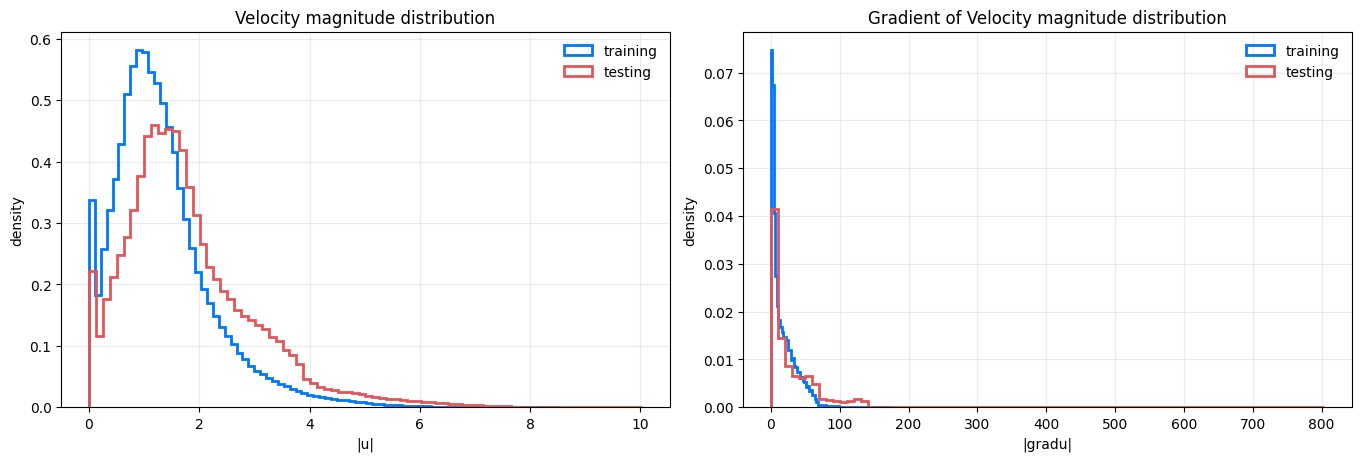

Saved: /home/dysco/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/final-2/result/task1/target_magnitude_distributions.png


In [12]:
# Plot target magnitude distributions 2 - train,test,validate.
# If these distributions are far apart, the model is being asked to extrapolate - one case - may or may not fail.

def collect_target_magnitudes_for_plot(frame_ids, maximum_frames=2000, maximum_particles_per_frame=1000000):
    if len(frame_ids) == 0:
        return None
    velocity_values = []
    gradient_values = []
    rng = np.random.default_rng(SEED)

    for frame_id in sample_frame_ids(frame_ids, maximum_frames, seed_offset=53):
        target = targets_by_frame_raw[int(frame_id)]
        if target.shape[0] > maximum_particles_per_frame:
            picked = rng.choice(target.shape[0], size=maximum_particles_per_frame, replace=False)
            target = target[picked]
        velocity_values.append(np.linalg.norm(target[:, :3], axis=1))
        gradient_values.append(np.linalg.norm(target[:, 3:], axis=1))

    return np.concatenate(velocity_values), np.concatenate(gradient_values)

plot_magnitudes = {
    'training': collect_target_magnitudes_for_plot(training_frame_ids),
    # 'validation': collect_target_magnitudes_for_plot(validation_frame_ids),
    'testing': collect_target_magnitudes_for_plot(testing_frame_ids),
}

figure, axes = plt.subplots(1, 2, figsize=(13.5, 4.5), constrained_layout=True)
colors = {'training': "#0278f7", 'validation': "#cdfec5", 'testing': '#e15759'}

for split_name, values in plot_magnitudes.items():
    if values is None:
        continue
    velocity_values, gradient_values = values
    axes[0].hist(velocity_values, bins=80, density=True, histtype='step', linewidth=2.0, color=colors[split_name], label=split_name)
    axes[1].hist(gradient_values, bins=80, density=True, histtype='step', linewidth=2.0, color=colors[split_name], label=split_name)



axes[0].set_title('Velocity magnitude distribution')
axes[0].set_xlabel('|u|')
axes[0].set_ylabel('density')
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False)

axes[1].set_title('Gradient of Velocity magnitude distribution')
axes[1].set_xlabel('|gradu|')
axes[1].set_ylabel('density')
axes[1].grid(alpha=0.25)
axes[1].legend(frameon=False)

plot_path = results_folder / 'target_magnitude_distributions.png'
figure.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', plot_path)


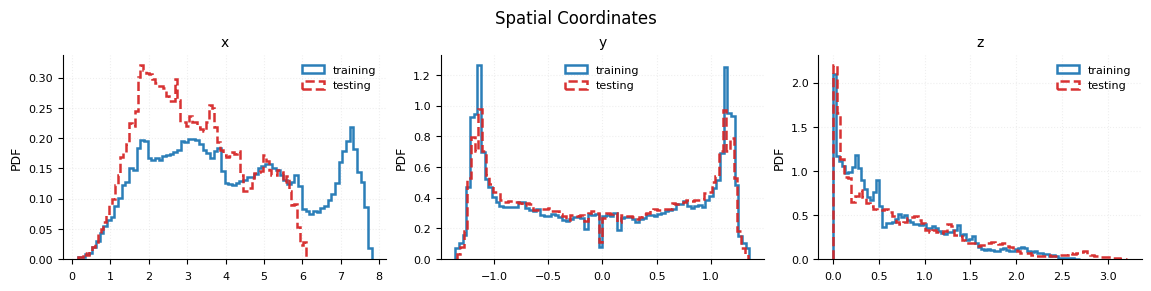

Saved: /home/dysco/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/final-2/result/task1/spatial_coordinates_distribution_plot.png


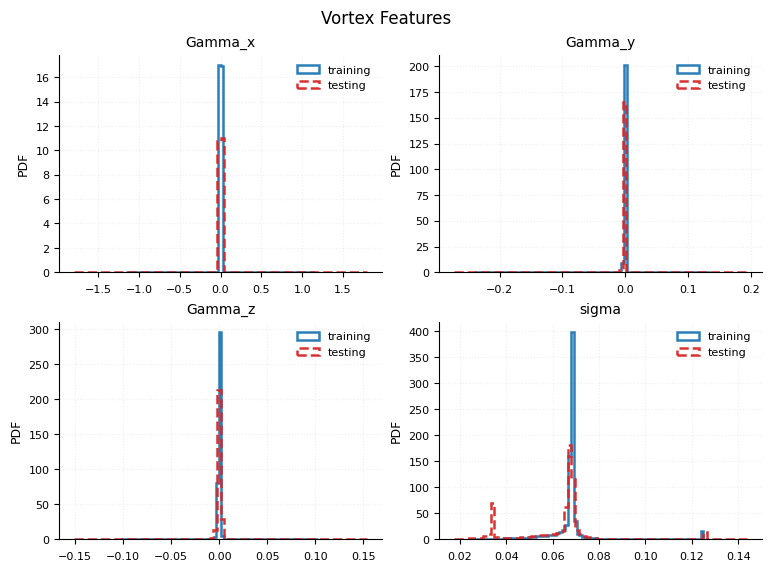

Saved: /home/dysco/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/final-2/result/task1/vortex_features_distribution_plot.png


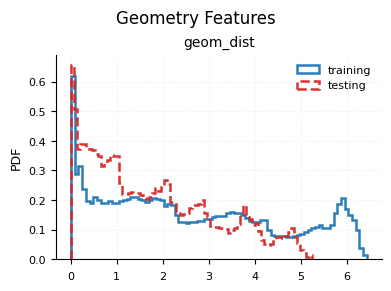

Saved: /home/dysco/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/final-2/result/task1/geometry_features_distribution_plot.png


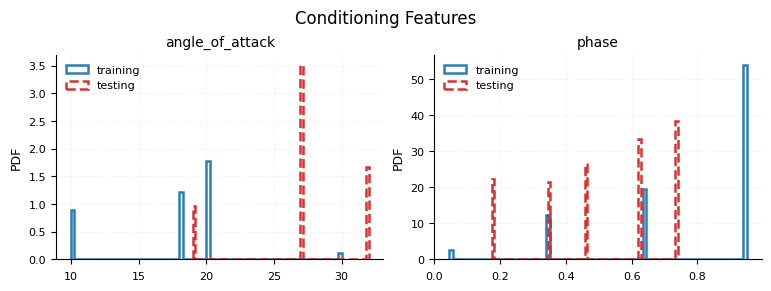

Saved: /home/dysco/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/final-2/result/task1/conditioning_features_distribution_plot.png


In [13]:
feature_groups = {
    'spatial_coordinates': ['x', 'y', 'z'],

    'vortex_features': [
        'Gamma_x',
        'Gamma_y',
        'Gamma_z',
        'Gamma_mag',
        'sigma',
    ],

    'geometry_features': [
        'geom_dist',
        'geom_body_near',
    ],

    'conditioning_features': [
        'angle_of_attack',
        'freestream_x',
        'freestream_z',
        'phase',
    ],
}


# Keep only existing features
feature_groups = {
    group_name: [
        feature for feature in feature_list
        if feature in feature_names
    ]
    for group_name, feature_list in feature_groups.items()
}


def collect_feature_values(
    frame_ids,
    feature_name,
    normalized=False,
    maximum_frames=5,
    maximum_particles_per_frame=1000000,
):

    if len(frame_ids) == 0:
        return None

    feature_index = feature_names.index(feature_name)

    values = []

    rng = np.random.default_rng(SEED + feature_index)

    source_arrays = (
        inputs_by_frame_normalized
        if normalized
        else inputs_by_frame_raw
    )

    for frame_id in sample_frame_ids(
        frame_ids,
        maximum_frames,
        seed_offset=53,
    ):

        frame = source_arrays[int(frame_id)]

        if frame.shape[0] > maximum_particles_per_frame:

            picked = rng.choice(
                frame.shape[0],
                size=maximum_particles_per_frame,
                replace=False,
            )

            frame = frame[picked]

        values.append(frame[:, feature_index])

    return np.concatenate(values)


# ---------------------------------------------------------
# Publication / ML-paper plotting style
# ---------------------------------------------------------

plt.rcParams.update({
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'legend.fontsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.linewidth': 0.8,
})


splits_for_plot = {
    'training': training_frame_ids,
    'testing': testing_frame_ids,
}


colors = {
    'training': '#1f77b4',
    'testing': '#d62728',
}


line_styles = {
    'training': '-',
    'testing': '--',   # dashed red
}


# ---------------------------------------------------------
# One figure per feature group
# ---------------------------------------------------------

for group_name, feature_list in feature_groups.items():

    if len(feature_list) == 0:
        continue

    n_features = len(feature_list)

    # -----------------------------------------
    # Layout logic
    # -----------------------------------------

    if n_features == 4:
        rows, cols = 2, 2
    else:
        cols = min(3, n_features)
        rows = int(np.ceil(n_features / cols))

    figure, axes = plt.subplots(
        rows,
        cols,
        figsize=(3.8 * cols, 2.8 * rows),
        constrained_layout=True,
    )

    axes = np.asarray(axes).reshape(-1)

    # -----------------------------------------
    # Plot features
    # -----------------------------------------

    for axis, feature_name in zip(axes, feature_list):

        for split_name, frame_ids in splits_for_plot.items():

            values = collect_feature_values(
                frame_ids,
                feature_name,
                normalized=False,
            )

            if values is None:
                continue

            axis.hist(
                values,
                bins=80,
                density=True,
                histtype='step',
                linewidth=1.8,
                linestyle=line_styles[split_name],
                color=colors[split_name],
                alpha=0.95,
                label=split_name,
            )

        # -------------------------------------
        # subplot formatting
        # -------------------------------------

        axis.set_title(feature_name)

        axis.set_ylabel('PDF')

        axis.grid(
            alpha=0.20,
            linestyle=':',
        )

        axis.spines['top'].set_visible(False)
        axis.spines['right'].set_visible(False)

        # Put x-axis labels BELOW the axis
        axis.tick_params(
            axis='x',
            direction='out',
            pad=5,
            bottom=True,
            top=False,
            labelbottom=True,
        )

        axis.xaxis.set_ticks_position('bottom')

        axis.legend(
            frameon=False,
            loc='best',
        )

    # -----------------------------------------
    # Remove empty axes
    # -----------------------------------------

    for axis in axes[n_features:]:
        axis.axis('off')

    # -----------------------------------------
    # Figure title
    # -----------------------------------------

    figure.suptitle(
        group_name.replace('_', ' ').title(),
        fontsize=12,
    )

    plot_path = (
        results_folder
        / f'{group_name}_distribution_plot.png'
    )

    figure.savefig(
        plot_path,
        dpi=400,
        bbox_inches='tight',
    )

    plt.show()

    print('Saved:', plot_path)

Data-pair visualization for GNO learning

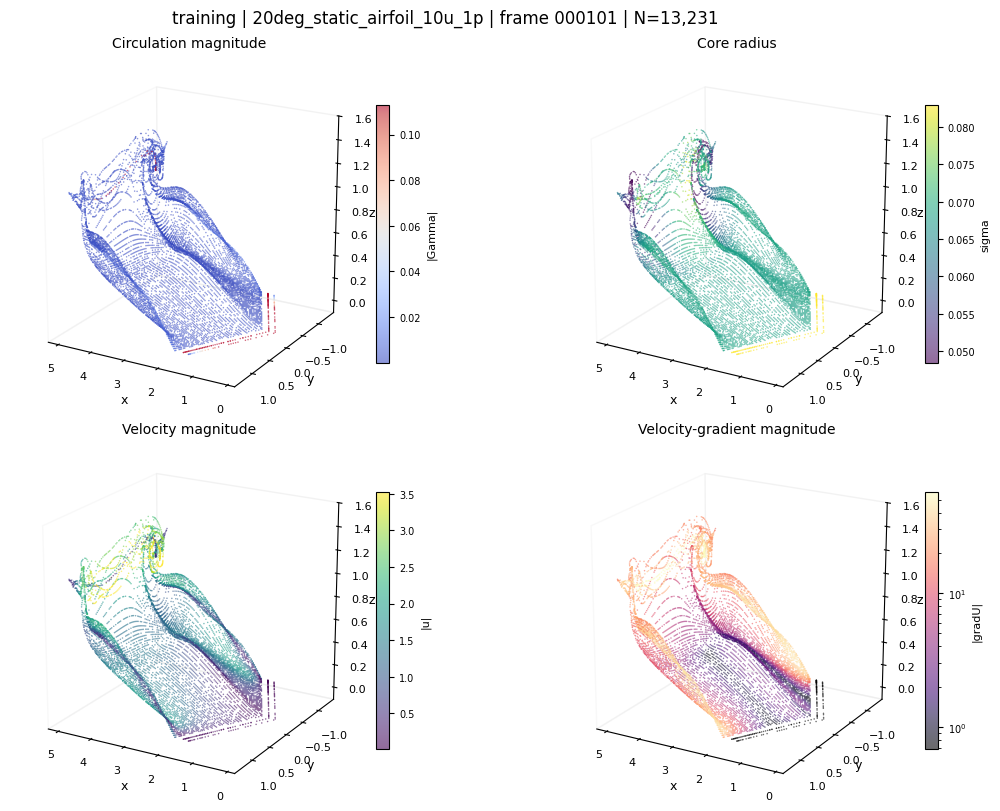

Saved: /home/dysco/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/final-2/result/task1/training_publication_cloud.png


In [14]:
from matplotlib.colors import LogNorm

plt.rcParams.update({
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.8,
    'figure.titlesize': 12,
})


split_frame_ids = {
    'training': training_frame_ids,
    # 'validation': validation_frame_ids,
    # 'validation_angle': validation_angle_frame_ids,
    # 'testing_normal': testing_normal_frame_ids,
    # 'testing_super_resolution': testing_super_resolution_frame_ids,
    # 'testing_unseen_angle': testing_unseen_angle_frame_ids,
}


split_colors = {
    'training': '#4c78a8',
    'validation': '#59a14f',
    'validation_angle': '#edc948',
    'testing_normal': '#e15759',
    'testing_super_resolution': '#b07aa1',
    'testing_unseen_angle': '#f28e2b',
}


# ---------------------------------------------------------
# helpers
# ---------------------------------------------------------

def feature_index_or_none(name):

    return (
        feature_names.index(name)
        if name in feature_names
        else None
    )


def target_index_or_none(name):

    return (
        target_names.index(name)
        if name in target_names
        else None
    )


def context_for_frame(frame_id):

    context = frame_contexts[int(frame_id)]

    return (
        context
        if isinstance(context, dict)
        else dict(context.item())
    )


def choose_representative_frame(frame_ids, split_name):

    if len(frame_ids) == 0:
        return None

    ordered = np.asarray(frame_ids, dtype=np.int64)

    # avoid earliest transient frames
    return int(ordered[len(ordered) // 2])


def sample_points_for_plot(
    input_raw,
    target_raw,
    maximum_points=9000,
    seed_offset=0,
):

    particle_count = input_raw.shape[0]

    if particle_count <= maximum_points:
        return input_raw, target_raw

    rng = np.random.default_rng(SEED + seed_offset)

    chosen = rng.choice(
        particle_count,
        size=maximum_points,
        replace=False,
    )

    return input_raw[chosen], target_raw[chosen]


def robust_color_limits(values, lower=2.0, upper=98.0):

    values = np.asarray(values)

    finite = values[np.isfinite(values)]

    if finite.size == 0:
        return 0.0, 1.0

    low, high = np.percentile(
        finite,
        [lower, upper],
    )

    if np.isclose(low, high):
        low, high = (
            float(finite.min()),
            float(finite.max()),
        )

    if np.isclose(low, high):
        high = low + 1.0

    return float(low), float(high)

def add_3d_cloud(
    axis,
    coordinates,
    color_values,
    title,
    colorbar_label,
    cmap='viridis',
    use_log=False,
):

    low, high = robust_color_limits(color_values)

    scatter_kwargs = dict(
        c=color_values,
        s=1.2,
        alpha=0.58,
        cmap=cmap,
        linewidths=0.0,
    )

    if use_log:

        scatter_kwargs['norm'] = LogNorm(
            vmin=max(low, 1e-6),
            vmax=high,
        )

    else:

        scatter_kwargs['vmin'] = low
        scatter_kwargs['vmax'] = high

    plot = axis.scatter(
        coordinates[:, 0],
        coordinates[:, 1],
        coordinates[:, 2],
        **scatter_kwargs,
    )


    axis.set_title(title, pad=6)


    axis.set_xlabel('x', labelpad=-4)
    axis.set_ylabel('y', labelpad=-4)
    axis.set_zlabel('z', labelpad=-4)

    axis.view_init(
        elev=20,
        azim=120,
    )


    axis.set_box_aspect([1, 1, 1])


    axis.xaxis.pane.fill = False
    axis.yaxis.pane.fill = False
    axis.zaxis.pane.fill = False

    axis.grid(False)


    axis.tick_params(
        axis='x',
        direction='out',
        pad=1,
        bottom=True,
        top=False,
        labelbottom=True,
    )

    colorbar = plt.colorbar(
        plot,
        ax=axis,
        shrink=0.72,
        pad=0.01,
        fraction=0.045,
    )

    colorbar.set_label(
        colorbar_label,
        fontsize=8,
    )

    colorbar.ax.tick_params(labelsize=7)


def plot_input_output_pair(split_name, frame_ids):

    frame_id = choose_representative_frame(
        frame_ids,
        split_name,
    )

    if frame_id is None:

        print(f'[{split_name}] no frames available.')

        return

    input_raw = inputs_by_frame_raw[frame_id]

    target_raw = targets_by_frame_raw[frame_id]

    input_plot, target_plot = sample_points_for_plot(
        input_raw,
        target_raw,
        seed_offset=frame_id,
    )

    x_i = feature_index_or_none('x')
    y_i = feature_index_or_none('y')
    z_i = feature_index_or_none('z')

    if None in (x_i, y_i, z_i):

        raise RuntimeError(
            'Expected x/y/z input features.'
        )

    coordinates = input_plot[:, [x_i, y_i, z_i]]

    # -----------------------------------------------------
    # circulation magnitude
    # -----------------------------------------------------

    gamma_columns = [
        feature_index_or_none(name)
        for name in [
            'Gamma_x',
            'Gamma_y',
            'Gamma_z',
        ]
    ]

    if all(index is not None for index in gamma_columns):

        circulation_color = np.linalg.norm(
            input_plot[:, gamma_columns],
            axis=1,
        )

        circulation_label = '|Gamma|'

    elif feature_index_or_none('Gamma_mag') is not None:

        circulation_color = input_plot[
            :,
            feature_index_or_none('Gamma_mag')
        ]

        circulation_label = 'Gamma_mag'

    else:

        circulation_color = np.zeros(
            input_plot.shape[0],
            dtype=np.float32,
        )

        circulation_label = 'circulation unavailable'

    # -----------------------------------------------------
    # sigma
    # -----------------------------------------------------

    sigma_i = feature_index_or_none('sigma')

    sigma_color = (
        input_plot[:, sigma_i]
        if sigma_i is not None
        else np.zeros(
            input_plot.shape[0],
            dtype=np.float32,
        )
    )

    # -----------------------------------------------------
    # targets
    # -----------------------------------------------------

    velocity_magnitude = np.linalg.norm(
        target_plot[:, :3],
        axis=1,
    )

    gradient_magnitude = np.linalg.norm(
        target_plot[:, 3:],
        axis=1,
    )

    # -----------------------------------------------------
    # metadata
    # -----------------------------------------------------

    context = context_for_frame(frame_id)

    case_name = str(
        context.get(
            'case',
            'unknown case',
        )
    )

    physical_frame = str(
        context.get(
            'frame',
            context.get('fr', 'unknown frame'),
        )
    )

    particle_count = int(
        context.get(
            'n_particles',
            input_raw.shape[0],
        )
    )

    figure = plt.figure(
        figsize=(11, 8),
        constrained_layout=True,
    )

    axes = [
        figure.add_subplot(
            2,
            2,
            i + 1,
            projection='3d',
        )
        for i in range(4)
    ]


    add_3d_cloud(
        axes[0],
        coordinates,
        circulation_color,
        'Circulation magnitude',
        circulation_label,
        cmap='coolwarm',
    )

    add_3d_cloud(
        axes[1],
        coordinates,
        sigma_color,
        'Core radius',
        'sigma',
        cmap='viridis',
    )

    add_3d_cloud(
        axes[2],
        coordinates,
        velocity_magnitude,
        'Velocity magnitude',
        '|u|',
        cmap='viridis',
    )

    add_3d_cloud(
        axes[3],
        coordinates,
        gradient_magnitude,
        'Velocity-gradient magnitude',
        '|gradU|',
        cmap='magma',
        use_log=True,
    )


    figure.suptitle(
        (
            f'{split_name} | '
            f'{case_name} | '
            f'frame {physical_frame} | '
            f'N={particle_count:,}'
        ),
        fontsize=12,
    )

    plot_path = (
        results_folder
        / f'{split_name.lower()}_publication_cloud.png'
    )

    figure.savefig(
        plot_path,
        dpi=350,
        bbox_inches='tight',
    )

    plt.show()

    print('Saved:', plot_path)


for split_name, frame_ids in split_frame_ids.items():

    plot_input_output_pair(
        split_name,
        frame_ids,
    )

50% of frames have 95th percentile |u| well below 3 - implied from cdf value plot

Frame-level summary quantiles
  training: frames=1760, particles median=13172, |u|95 median=2.868, |gradU|95 median=45.99


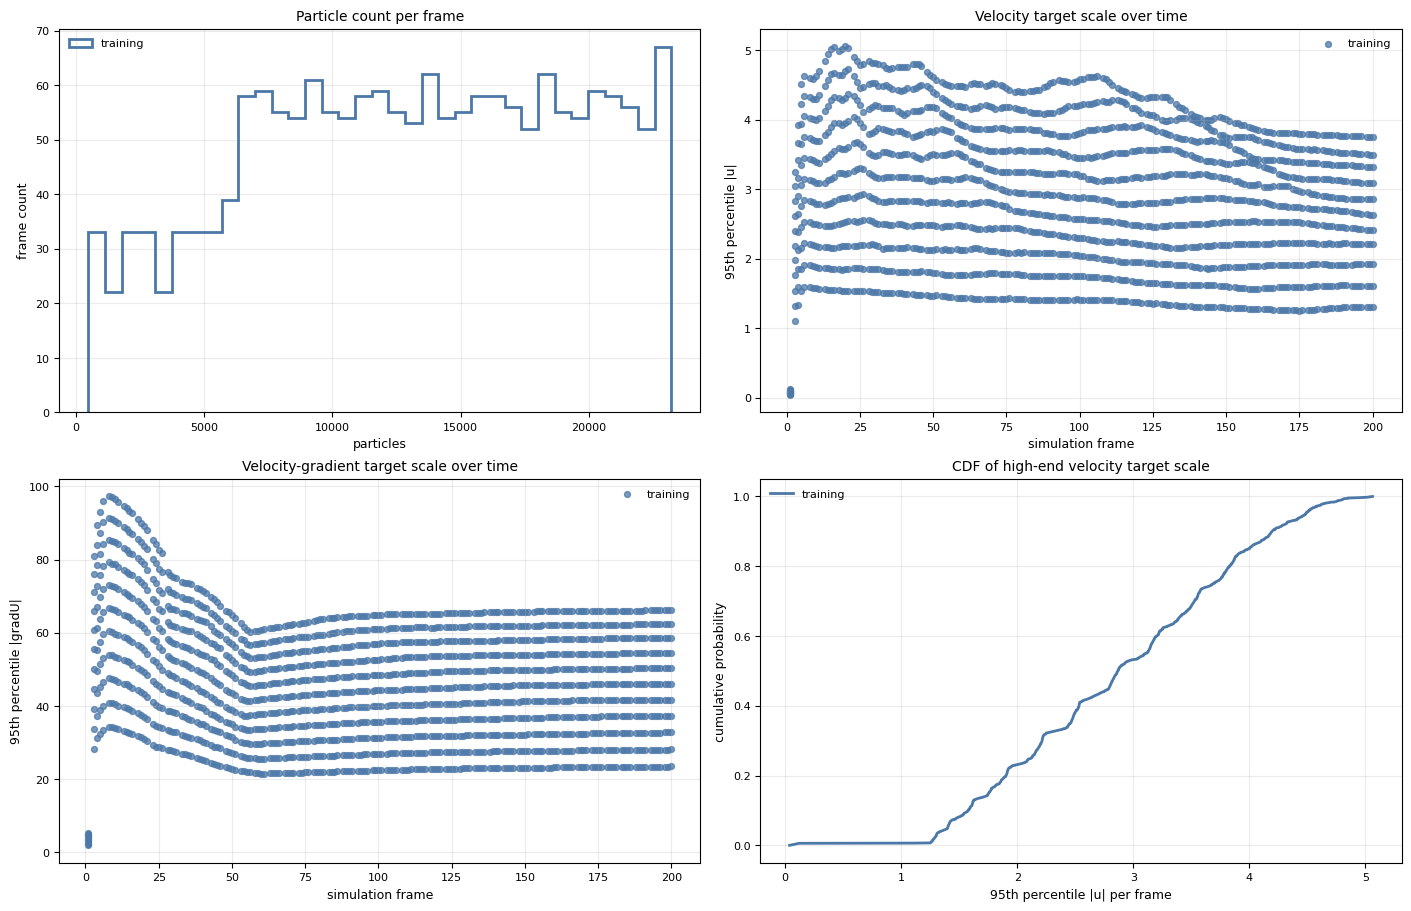

Saved: /home/dysco/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/final-2/result/task1/gno_data_pair_distribution_summary.png


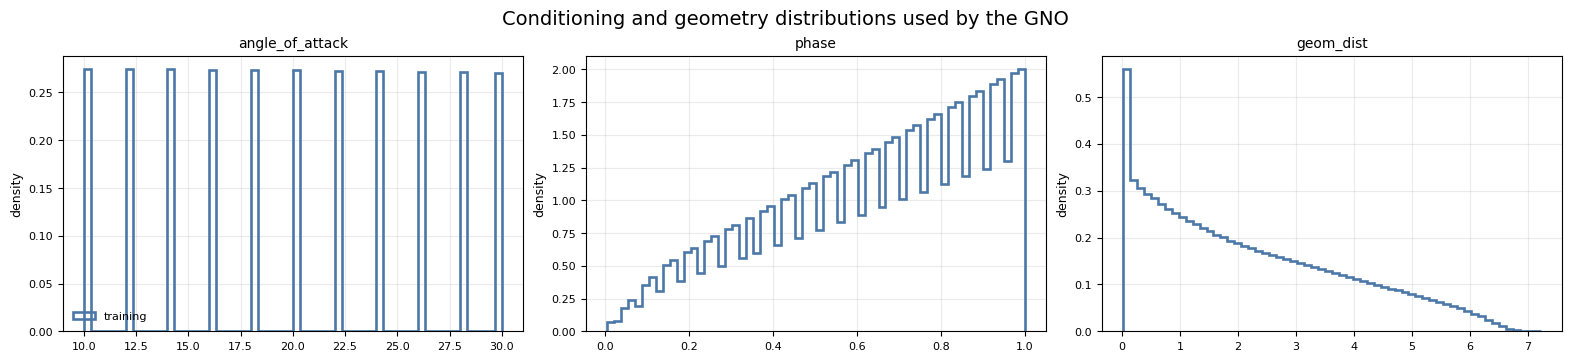

Saved: /home/dysco/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/final-2/result/task1/gno_conditioning_geometry_distributions.png


In [15]:
# Split-level distribution diagnostics for GNO learning.
# These plots reveal whether validation/testing require interpolation or extrapolation in particle count,
# AoA/phase, local geometry, and target magnitude.


def collect_frame_level_summary(frame_ids, maximum_frames=2000, maximum_particles_per_frame=1000000):
    rows = []
    rng = np.random.default_rng(SEED + 991)
    for frame_id in sample_frame_ids(frame_ids, maximum_frames, seed_offset=53):
        input_raw = inputs_by_frame_raw[int(frame_id)]
        target_raw = targets_by_frame_raw[int(frame_id)]
        if input_raw.shape[0] > maximum_particles_per_frame:
            chosen = rng.choice(input_raw.shape[0], size=maximum_particles_per_frame, replace=False)
            input_used = input_raw[chosen]
            target_used = target_raw[chosen]
        else:
            input_used = input_raw
            target_used = target_raw

        context = context_for_frame(int(frame_id))
        row = {
            'frame_id': int(frame_id),
            'case': str(context.get('case', 'unknown')),
            'physical_frame': float(context.get('frame', context.get('fr', np.nan))),
            'particle_count': int(input_raw.shape[0]),
            'velocity_median': float(np.median(np.linalg.norm(target_used[:, :3], axis=1))),
            'velocity_95': float(np.percentile(np.linalg.norm(target_used[:, :3], axis=1), 95)),
            'gradient_median': float(np.median(np.linalg.norm(target_used[:, 3:], axis=1))),
            'gradient_95': float(np.percentile(np.linalg.norm(target_used[:, 3:], axis=1), 95)),
        }

        for optional_feature in ['angle_of_attack', 'phase', 'geom_dist', 'geom_body_near', 'nearest_particle_distance', 'local_neighbor_count']:
            feature_i = feature_index_or_none(optional_feature)
            if feature_i is not None:
                row[optional_feature] = float(np.median(input_used[:, feature_i]))
        rows.append(row)
    return rows


summary_by_split = {
    split_name: collect_frame_level_summary(frame_ids)
    for split_name, frame_ids in split_frame_ids.items()
}

print('Frame-level summary quantiles')
for split_name, rows in summary_by_split.items():
    if len(rows) == 0:
        print(f'  {split_name}: no frames')
        continue
    particle_counts = np.asarray([row['particle_count'] for row in rows], dtype=np.float64)
    velocity_95 = np.asarray([row['velocity_95'] for row in rows], dtype=np.float64)
    gradient_95 = np.asarray([row['gradient_95'] for row in rows], dtype=np.float64)
    print(
        f"  {split_name}: frames={len(rows)}, "
        f"particles median={np.median(particle_counts):.0f}, "
        f"|u|95 median={np.median(velocity_95):.4g}, "
        f"|gradU|95 median={np.median(gradient_95):.4g}"
    )

figure, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

for split_name, rows in summary_by_split.items():
    if len(rows) == 0:
        continue
    color = split_colors[split_name]
    particle_counts = np.asarray([row['particle_count'] for row in rows], dtype=np.float64)
    velocity_95 = np.asarray([row['velocity_95'] for row in rows], dtype=np.float64)
    gradient_95 = np.asarray([row['gradient_95'] for row in rows], dtype=np.float64)
    frames = np.asarray([row['physical_frame'] for row in rows], dtype=np.float64)

    axes[0, 0].hist(particle_counts, bins=35, histtype='step', linewidth=2.0, color=color, label=split_name)
    axes[0, 1].scatter(frames, velocity_95, s=18, alpha=0.75, color=color, label=split_name)
    axes[1, 0].scatter(frames, gradient_95, s=18, alpha=0.75, color=color, label=split_name)

    sorted_velocity = np.sort(velocity_95)
    cdf = np.linspace(0.0, 1.0, sorted_velocity.size, endpoint=True)
    axes[1, 1].plot(sorted_velocity, cdf, linewidth=2.0, color=color, label=split_name)

axes[0, 0].set_title('Particle count per frame')
axes[0, 0].set_xlabel('particles')
axes[0, 0].set_ylabel('frame count')
axes[0, 0].grid(alpha=0.25)
axes[0, 0].legend(frameon=False)

axes[0, 1].set_title('Velocity target scale over time')
axes[0, 1].set_xlabel('simulation frame')
axes[0, 1].set_ylabel('95th percentile |u|')
axes[0, 1].grid(alpha=0.25)
axes[0, 1].legend(frameon=False)

axes[1, 0].set_title('Velocity-gradient target scale over time')
axes[1, 0].set_xlabel('simulation frame')
axes[1, 0].set_ylabel('95th percentile |gradU|')
axes[1, 0].grid(alpha=0.25)
axes[1, 0].legend(frameon=False)

axes[1, 1].set_title('CDF of high-end velocity target scale')
axes[1, 1].set_xlabel('95th percentile |u| per frame')
axes[1, 1].set_ylabel('cumulative probability')
axes[1, 1].grid(alpha=0.25)
axes[1, 1].legend(frameon=False)

plot_path = results_folder / 'gno_data_pair_distribution_summary.png'
figure.savefig(plot_path, dpi=220, bbox_inches='tight')
plt.show()
print('Saved:', plot_path)

# Optional conditioning/geometry panel: drawn only for features present in the preprocessed file.
optional_panels = [name for name in ['angle_of_attack', 'phase', 'geom_dist', 'nearest_particle_distance', 'local_neighbor_count'] if name in feature_names]
if optional_panels:
    columns = min(3, len(optional_panels))
    rows = int(np.ceil(len(optional_panels) / columns))
    figure, axes = plt.subplots(rows, columns, figsize=(5.2 * columns, 3.5 * rows), constrained_layout=True)
    axes = np.asarray(axes).reshape(-1)

    for axis, feature_name in zip(axes, optional_panels):
        for split_name, frame_ids in split_frame_ids.items():
            values = collect_feature_values(frame_ids, feature_name, normalized=False, maximum_frames=2000, maximum_particles_per_frame=1000000)
            if values is None:
                continue
            axis.hist(values, bins=60, density=True, histtype='step', linewidth=1.9, color=split_colors[split_name], label=split_name)
        axis.set_title(feature_name)
        axis.set_ylabel('density')
        axis.grid(alpha=0.25)

    for axis in axes[len(optional_panels):]:
        axis.axis('off')
    axes[0].legend(frameon=False)
    figure.suptitle('Conditioning and geometry distributions used by the GNO', fontsize=14)
    plot_path = results_folder / 'gno_conditioning_geometry_distributions.png'
    figure.savefig(plot_path, dpi=220, bbox_inches='tight')
    plt.show()
    print('Saved:', plot_path)
else:
    print('No conditioning/geometry features found for the optional distribution panel.')


In [16]:
# One item is one simulation frame. The frame contains many particles, so the model sees a graph.

class ParticleFrameDataset(Dataset):
    def __init__(self, frame_ids):
        self.frame_ids = [int(frame_id) for frame_id in frame_ids]

    def __len__(self):
        return len(self.frame_ids)

    def __getitem__(self, index):
        frame_id = self.frame_ids[index]
        input_normalized = torch.from_numpy(inputs_by_frame_normalized[frame_id])
        target_normalized = torch.from_numpy(targets_by_frame_normalized[frame_id])
        input_raw = torch.from_numpy(inputs_by_frame_raw[frame_id])
        context = frame_contexts[frame_id]
        metadata = {
            'frame_id': frame_id,
            'case': str(context.get('case', 'unknown')),
            'frame': str(context.get('frame', context.get('fr', 'unknown'))),
            'particle_count': int(context.get('n_particles', input_normalized.shape[0])),
        }
        return input_normalized, target_normalized, input_raw, metadata


def collate_one_frame(batch):
    # Batch size is one frame. Returning lists keeps variable particle counts simple.
    inputs, targets, raw_inputs, metadata = zip(*batch)
    return list(inputs), list(targets), list(raw_inputs), list(metadata)

training_dataset = ParticleFrameDataset(training_frame_ids)
validation_dataset = ParticleFrameDataset(validation_frame_ids)
testing_dataset = ParticleFrameDataset(testing_frame_ids)
testing_normal_dataset = ParticleFrameDataset(testing_normal_frame_ids)
testing_super_resolution_dataset = ParticleFrameDataset(testing_super_resolution_frame_ids)
testing_unseen_angle_dataset = ParticleFrameDataset(testing_unseen_angle_frame_ids)

training_loader = DataLoader(training_dataset, batch_size=1, shuffle=True, collate_fn=collate_one_frame)
validation_loader = DataLoader(validation_dataset, batch_size=1, shuffle=False, collate_fn=collate_one_frame)
testing_loader = DataLoader(testing_dataset, batch_size=1, shuffle=False, collate_fn=collate_one_frame)
testing_normal_loader = DataLoader(testing_normal_dataset, batch_size=1, shuffle=False, collate_fn=collate_one_frame)
testing_super_resolution_loader = DataLoader(testing_super_resolution_dataset, batch_size=1, shuffle=False, collate_fn=collate_one_frame)
testing_unseen_angle_loader = DataLoader(testing_unseen_angle_dataset, batch_size=1, shuffle=False, collate_fn=collate_one_frame)

sample_input, sample_target, sample_raw, sample_metadata = training_dataset[0]
print('One frame input shape :', tuple(sample_input.shape))
print('One frame target shape:', tuple(sample_target.shape))
print('Example metadata      :', sample_metadata)


One frame input shape : (501, 13)
One frame target shape: (501, 12)
Example metadata      : {'frame_id': 1, 'case': '10deg_static_airfoil_10u_1p', 'frame': '000001', 'particle_count': 501}


GNO layers with batch size following gradient accumulation.

In [17]:
try:
    from neuralop.layers.neighbor_search import NeighborSearch
except Exception as error:
    raise RuntimeError('This notebook needs neuralop with NeighborSearch installed in the active environment.') from error


def relative_l2_error(prediction, target, small_number=1e-12):
    difference = (prediction - target).reshape(prediction.shape[0], -1)
    reference = target.reshape(target.shape[0], -1)
    return (torch.linalg.norm(difference, dim=1) / torch.linalg.norm(reference, dim=1).clamp_min(small_number)).mean()


class EdgeFeatureMessageBlock(nn.Module):
    """Radius-graph message block with explicit vortex-inspired edge features.

    Connectivity is still spatial: particles exchange messages with nearby particles in xyz space.
    The message itself receives richer pairwise information: relative displacement, distance,
    sigma-scaled distances, source/target Gamma, and source/target sigma.
    """

    def __init__(self, hidden_size, neighbor_radius, use_open3d_neighbor_search=True, dropout=0.04):
        super().__init__()
        self.neighbor_radius = float(neighbor_radius)
        self.neighbor_search = NeighborSearch(use_open3d=use_open3d_neighbor_search, return_norm=False)

        # Edge feature layout:
        #   hidden_source, hidden_target: 2 * hidden_size
        #   dx, dy, dz: 3
        #   distance: 1
        #   distance / sigma_source, distance / sigma_target: 2
        #   Gamma_source xyz, Gamma_target xyz: 6
        #   sigma_source, sigma_target: 2
        edge_feature_size = 2 * hidden_size + 14
        self.message_network = nn.Sequential(
            nn.Linear(edge_feature_size, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Linear(hidden_size, hidden_size),
        )
        self.normalization = nn.LayerNorm(hidden_size)
        self.edge_feature_size = edge_feature_size

    def forward(self, hidden, search_positions, physical_positions, gamma_values, sigma_values):
        neighbors = self.neighbor_search(
            data=search_positions,
            queries=search_positions,
            radius=self.neighbor_radius,
        )
        source_index = neighbors['neighbors_index'].long()
        row_splits = neighbors['neighbors_row_splits'].long()
        neighbor_counts = row_splits[1:] - row_splits[:-1]

        if source_index.numel() == 0:
            return hidden

        target_index = torch.repeat_interleave(
            torch.arange(search_positions.shape[0], device=search_positions.device),
            neighbor_counts,
        )

        source_hidden = hidden[source_index]
        target_hidden = hidden[target_index]

        # Use physical/preprocessed coordinates for edge descriptors, while connectivity can still use normalized xyz.
        relative_position = physical_positions[source_index] - physical_positions[target_index]
        distance = torch.linalg.norm(relative_position, dim=-1, keepdim=True)

        sigma_source = sigma_values[source_index].abs().clamp_min(1.0e-8)
        sigma_target = sigma_values[target_index].abs().clamp_min(1.0e-8)
        gamma_source = gamma_values[source_index]
        gamma_target = gamma_values[target_index]

        edge_features = torch.cat(
            [
                source_hidden,
                target_hidden,
                relative_position,
                distance,
                distance / sigma_source,
                distance / sigma_target,
                gamma_source,
                gamma_target,
                sigma_source,
                sigma_target,
            ],
            dim=-1,
        )
        messages = self.message_network(edge_features)

        # aggregated = torch.zeros_like(hidden)
        aggregated = torch.zeros(
        hidden.shape,
        device=hidden.device,
        dtype=messages.dtype
        )
        aggregated.index_add_(0, target_index, messages)
        aggregated = aggregated / neighbor_counts.to(hidden.dtype).clamp_min(1.0).unsqueeze(-1)

        return self.normalization(hidden + aggregated)


class ParticleVelocityGradientModel(nn.Module):
    def __init__(
        self,
        input_size,
        output_size,
        feature_names,
        input_mean,
        input_standard_deviation,
        hidden_size=96,
        graph_layers=2,
        neighbor_radius=0.12,
        dropout=0.04,
        use_physical_edge_features=True,
    ):
        super().__init__()
        self.neighbor_radius = float(neighbor_radius)
        self.feature_names = list(feature_names)
        self.use_physical_edge_features = bool(use_physical_edge_features)

        # Store normalization statistics so the edge block can recover physical/preprocessed Gamma/sigma/xyz values.
        self.register_buffer('input_mean', torch.as_tensor(input_mean, dtype=torch.float32).reshape(1, -1))
        self.register_buffer('input_standard_deviation', torch.as_tensor(input_standard_deviation, dtype=torch.float32).reshape(1, -1))

        self.sigma_index = self.feature_names.index('sigma') if 'sigma' in self.feature_names else -1
        self.gamma_indices = [self.feature_names.index(name) for name in ['Gamma_x', 'Gamma_y', 'Gamma_z'] if name in self.feature_names]
        if len(self.gamma_indices) != 3:
            self.gamma_indices = []

        # Per-particle encoder: maps particle/state/conditioning channels into a learned latent representation.
        self.input_network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Linear(hidden_size, hidden_size),
        )

        # Open3D is optional. If unavailable, NeighborSearch falls back to native PyTorch search.
        try:
            import open3d  # noqa: F401
            use_open3d = True
        except Exception:
            use_open3d = False

        self.graph_blocks = nn.ModuleList([
            EdgeFeatureMessageBlock(
                hidden_size=hidden_size,
                neighbor_radius=self.neighbor_radius,
                use_open3d_neighbor_search=use_open3d,
                dropout=dropout,
            )
            for _ in range(graph_layers)
        ])

        self.output_network = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, output_size),
        )

        self.backend_information = {
            'neighbor_search': 'open3d' if use_open3d else 'native_torch',
            'edge_features': 'dx, distance, distance/sigma, Gamma_source/target, sigma_source/target',
            'use_physical_edge_features': self.use_physical_edge_features,
        }

    def physical_feature_values(self, particle_features):
        if not self.use_physical_edge_features:
            return particle_features
        return particle_features * self.input_standard_deviation.to(particle_features.dtype) + self.input_mean.to(particle_features.dtype)

    def forward(self, particle_features):
        # Connectivity remains based on xyz only, because locality in physical space decides who interacts.
        search_positions = particle_features[:, :3]
        physical_features = self.physical_feature_values(particle_features)
        physical_positions = physical_features[:, :3]

        if self.sigma_index >= 0:
            sigma_values = physical_features[:, self.sigma_index:self.sigma_index + 1]
        else:
            sigma_values = torch.ones((particle_features.shape[0], 1), device=particle_features.device, dtype=particle_features.dtype)

        if self.gamma_indices:
            gamma_values = physical_features[:, self.gamma_indices]
        else:
            gamma_values = torch.zeros((particle_features.shape[0], 3), device=particle_features.device, dtype=particle_features.dtype)

        hidden = self.input_network(particle_features)
        for graph_block in self.graph_blocks:
            hidden = graph_block(
                hidden=hidden,
                search_positions=search_positions,
                physical_positions=physical_positions,
                gamma_values=gamma_values,
                sigma_values=sigma_values,
            )

        return self.output_network(hidden)


# Change this for an ablation run. Use 'baseline' first, then 'larger' only if the baseline learns.
model_size = 'larger'  # choices: 'tiny', 'baseline', 'larger'
model_options = {
    'tiny': {'hidden_size': 64, 'graph_layers': 1, 'neighbor_radius': 0.08, 'dropout': 0.04},
    'baseline': {'hidden_size': 96, 'graph_layers': 2, 'neighbor_radius': 0.10, 'dropout': 0.04},
    'larger': {'hidden_size': 128, 'graph_layers': 3, 'neighbor_radius': 0.12, 'dropout': 0.06},
}
model_config = model_options[model_size]

model = ParticleVelocityGradientModel(
    input_size=input_dimension,
    output_size=output_dimension,
    feature_names=feature_names,
    input_mean=input_mean,
    input_standard_deviation=input_standard_deviation,
    **model_config,
).to(device)

trainable_parameter_count = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print('Model size:', model_size)
print('Model config:', model_config)
print('Trainable parameters:', f'{trainable_parameter_count:,}')
print('Graph backend info  :', model.backend_information)

# print('mean neighbors:', neighbor_counts.float().mean().item())
# print('max neighbors :', neighbor_counts.max().item())



Model size: larger
Model config: {'hidden_size': 128, 'graph_layers': 3, 'neighbor_radius': 0.12, 'dropout': 0.06}
Trainable parameters: 256,780
Graph backend info  : {'neighbor_search': 'native_torch', 'edge_features': 'dx, distance, distance/sigma, Gamma_source/target, sigma_source/target', 'use_physical_edge_features': True}


In [18]:
# Training settings.
# Start with quick_check. For final training, switch to better_check.

training_profile = 'better_check'      # choices: 'quick_check', 'better_check'
training_frame_selection = 'all_frames'   # choices: 'random_subset', 'all_frames', 'stride'
training_frame_stride = 2             # used only when training_frame_selection='stride'
loss_name = 'smooth_l1'               # choices: 'smooth_l1', 'mse', 'relative_l2'

profiles = {
    'quick_check': {
        'epochs': 12,
        'frames_per_epoch': 12,
        'particles_per_frame_start': 768,
        'particles_per_frame_final': 2048,
        'maximum_particles_before_gpu': 6000,
        'validation_frames_per_check': 8,
        # Accumulate gradients over this many variable-size frames before optimizer.step().
        # This gives effective batch size > 1 without padding particle clouds to equal size.
        'gradient_accumulation_steps': 4,
        'check_every_epochs': 1,
    },
    'better_check': {
        'epochs': 60,
        'frames_per_epoch': 28,
        'particles_per_frame_start': 1024,
        'particles_per_frame_final': 4096,
        'maximum_particles_before_gpu': 12000,
        'validation_frames_per_check': 16,
        # Increase this if GPU memory is tight but optimization is noisy.
        # Memory stays close to batch_size=1 because only gradients are accumulated.
        'gradient_accumulation_steps': 4,
        'check_every_epochs': 2,
    },
}
settings = dict(profiles[training_profile])

if training_frame_selection == 'all_frames':
    settings['frames_per_epoch'] = len(training_dataset)
elif training_frame_selection == 'stride':
    # One-in-N frames per epoch. The offset rotates each epoch, so stride=6 sees all frames over six epochs.
    settings['frames_per_epoch'] = int(np.ceil(len(training_dataset) / max(int(training_frame_stride), 1)))
elif training_frame_selection == 'random_subset':
    settings['frames_per_epoch'] = min(settings['frames_per_epoch'], len(training_dataset))
else:
    raise ValueError("training_frame_selection must be 'random_subset', 'all_frames', or 'stride'")

initial_learning_rate = 3e-4
minimum_learning_rate = 5e-6
weight_decay = 3e-5
# Loss balancing between the two physical tasks.
# Default here follows the statistically normalized multi-task loss:
#   L = MSE(u) / std(u_train)^2 + MSE(gradU) / std(gradU_train)^2
# The std values are computed from TRAINING targets only.
loss_balance_mode = 'variance_normalized_physical_mse'
# Other choices: 'equal_task_mean', 'manual'
manual_velocity_loss_weight = 1.0      # used only when loss_balance_mode='manual'
manual_gradient_loss_weight = 1.0      # used only when loss_balance_mode='manual'
smooth_l1_beta = 0.06
gradient_clip_norm = 1.0



def training_task_standard_deviations(frame_ids):
    # Compute scalar task scales from raw TRAINING targets only.
    # This is the exact notebook equivalent of:
    #   u_std = train_targets[:, :3].std()
    #   gradU_std = train_targets[:, 3:].std()
    # but done frame-by-frame to avoid concatenating the whole dataset in memory.
    velocity_count = 0
    velocity_sum = 0.0
    velocity_square_sum = 0.0
    gradient_count = 0
    gradient_sum = 0.0
    gradient_square_sum = 0.0

    for frame_id in np.asarray(frame_ids, dtype=np.int64):
        target = targets_by_frame_raw[int(frame_id)].astype(np.float64, copy=False)
        velocity = target[:, :3].reshape(-1)
        gradient = target[:, 3:].reshape(-1)

        velocity_count += velocity.size
        velocity_sum += float(velocity.sum())
        velocity_square_sum += float(np.dot(velocity, velocity))

        gradient_count += gradient.size
        gradient_sum += float(gradient.sum())
        gradient_square_sum += float(np.dot(gradient, gradient))

    velocity_mean = velocity_sum / max(velocity_count, 1)
    gradient_mean = gradient_sum / max(gradient_count, 1)
    velocity_variance = max(velocity_square_sum / max(velocity_count, 1) - velocity_mean ** 2, 1e-12)
    gradient_variance = max(gradient_square_sum / max(gradient_count, 1) - gradient_mean ** 2, 1e-12)
    return float(np.sqrt(velocity_variance)), float(np.sqrt(gradient_variance))


velocity_task_std_value, gradient_task_std_value = training_task_standard_deviations(training_frame_ids)
velocity_task_std = torch.tensor(velocity_task_std_value, dtype=torch.float32, device=device)
gradient_task_std = torch.tensor(gradient_task_std_value, dtype=torch.float32, device=device)

optimizer = torch.optim.AdamW(model.parameters(), lr=initial_learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=settings['epochs'],
    eta_min=minimum_learning_rate,
)

use_mixed_precision = device.type == 'cuda'
mixed_precision_dtype = torch.bfloat16 if (use_mixed_precision and torch.cuda.is_bf16_supported()) else torch.float16
try:
    scaler = torch.amp.GradScaler('cuda', enabled=bool(use_mixed_precision and mixed_precision_dtype == torch.float16))
except Exception:
    scaler = torch.cuda.amp.GradScaler(enabled=bool(use_mixed_precision and mixed_precision_dtype == torch.float16))
autocast_options = dict(device_type=device.type, dtype=mixed_precision_dtype, enabled=use_mixed_precision)

if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
    try:
        torch.set_float32_matmul_precision('high')
    except Exception:
        pass

print('Training profile:', training_profile)
print('Training frame selection:', training_frame_selection)
print('Training frame stride:', training_frame_stride if training_frame_selection == 'stride' else 'not used')
print('Gradient accumulation steps:', settings['gradient_accumulation_steps'])
print('Effective frame batch size:', settings['gradient_accumulation_steps'])
print('Loss:', loss_name)
print(json.dumps(settings, indent=2))
print('Initial learning rate:', initial_learning_rate)
print('Minimum learning rate:', minimum_learning_rate)
print('Loss balance mode:', loss_balance_mode)
print('Training velocity std:', f'{velocity_task_std_value:.6e}')
print('Training gradU std   :', f'{gradient_task_std_value:.6e}')
if loss_balance_mode == 'manual':
    print('Manual velocity loss weight:', manual_velocity_loss_weight)
    print('Manual velocity-gradient loss weight:', manual_gradient_loss_weight)
elif loss_balance_mode == 'equal_task_mean':
    print('Task weighting: 0.5 * velocity_loss + 0.5 * velocity_gradient_loss')
elif loss_balance_mode == 'variance_normalized_physical_mse':
    print('Task weighting: MSE(u_phys)/u_std^2 + MSE(gradU_phys)/gradU_std^2')
print('Mixed precision:', use_mixed_precision, str(mixed_precision_dtype))



Training profile: better_check
Training frame selection: all_frames
Training frame stride: not used
Gradient accumulation steps: 4
Effective frame batch size: 4
Loss: smooth_l1
{
  "epochs": 60,
  "frames_per_epoch": 1760,
  "particles_per_frame_start": 1024,
  "particles_per_frame_final": 4096,
  "maximum_particles_before_gpu": 12000,
  "validation_frames_per_check": 16,
  "gradient_accumulation_steps": 4,
  "check_every_epochs": 2
}
Initial learning rate: 0.0003
Minimum learning rate: 5e-06
Loss balance mode: variance_normalized_physical_mse
Training velocity std: 9.372389e-01
Training gradU std   : 8.292488e+00
Task weighting: MSE(u_phys)/u_std^2 + MSE(gradU_phys)/gradU_std^2
Mixed precision: False torch.float16


In [19]:
# Helper functions for sampling, loss, and metrics.
# The model trains on normalized targets. Metrics are reported after converting back to physical units.

# Relative error is undefined when the true target is exactly zero.
# Some frame-0 targets are zero, so we skip those frames for relative-error averages
# and report RMSE/MAE as stable absolute-error diagnostics.
minimum_target_norm_for_relative_error = 1e-6


def denormalize_target(target_normalized):
    return target_normalized * output_standard_deviation + output_mean


def particle_cap_for_epoch(epoch_number):
    if settings['epochs'] <= 1:
        return settings['particles_per_frame_final']
    progress = (epoch_number - 1) / max(settings['epochs'] - 1, 1)
    start = settings['particles_per_frame_start']
    final = settings['particles_per_frame_final']
    return int(round((1.0 - progress) * start + progress * final))


def subsample_before_gpu(input_tensor, target_tensor, raw_input_tensor, maximum_particles):
    # This limits extremely large frames before GPU transfer.
    particle_count = input_tensor.shape[0]
    if particle_count <= maximum_particles:
        return input_tensor, target_tensor, raw_input_tensor
    picked = torch.randperm(particle_count)[:maximum_particles]
    return input_tensor[picked], target_tensor[picked], raw_input_tensor[picked]


def subsample_for_training(input_tensor, target_tensor, raw_input_tensor, particle_cap):
    # This is the within-frame particle curriculum. It keeps quick checks affordable.
    particle_count = input_tensor.shape[0]
    if particle_count <= particle_cap:
        return input_tensor, target_tensor, raw_input_tensor
    picked = torch.randperm(particle_count, device=input_tensor.device)[:particle_cap]
    return input_tensor[picked], target_tensor[picked], raw_input_tensor[picked]


def channel_loss(prediction, target):
    if loss_name == 'mse':
        return (prediction - target) ** 2
    if loss_name == 'relative_l2':
        numerator = (prediction - target) ** 2
        denominator = torch.mean(target ** 2, dim=0, keepdim=True).clamp_min(1e-8)
        return numerator / denominator
    if loss_name == 'smooth_l1':
        return F.smooth_l1_loss(prediction, target, reduction='none', beta=smooth_l1_beta)
    raise ValueError(f'Unknown loss_name: {loss_name}')


def weighted_training_loss(prediction, target):
    # For the variance-normalized option, compute MSE in physical units and
    # divide each task by the variance measured from training targets only.
    # This directly implements:
    #   L = MSE(u) / std(u_train)^2 + MSE(gradU) / std(gradU_train)^2
    if loss_balance_mode == 'variance_normalized_physical_mse':
        prediction_physical = denormalize_target(prediction)
        target_physical = denormalize_target(target)
        velocity_loss = torch.mean((prediction_physical[:, :3] - target_physical[:, :3]) ** 2) / velocity_task_std.clamp_min(1e-12) ** 2
        velocity_gradient_loss = torch.mean((prediction_physical[:, 3:] - target_physical[:, 3:]) ** 2) / gradient_task_std.clamp_min(1e-12) ** 2
        total_loss = velocity_loss + velocity_gradient_loss
        return total_loss, velocity_loss.detach(), velocity_gradient_loss.detach()

    # For normalized-target options, prediction and target are already in standardized target space.
    point_loss = channel_loss(prediction, target)
    velocity_loss = point_loss[:, :3].mean()
    velocity_gradient_loss = point_loss[:, 3:].mean()

    if loss_balance_mode == 'equal_task_mean':
        total_loss = 0.5 * velocity_loss + 0.5 * velocity_gradient_loss
    elif loss_balance_mode == 'manual':
        total_loss = manual_velocity_loss_weight * velocity_loss + manual_gradient_loss_weight * velocity_gradient_loss
    else:
        raise ValueError(f'Unknown loss_balance_mode: {loss_balance_mode}')

    return total_loss, velocity_loss.detach(), velocity_gradient_loss.detach()


def component_metrics(prediction, target):
    # Return absolute metrics and a safe relative L2 value for one tensor block.
    difference = prediction - target
    target_norm = torch.linalg.norm(target.reshape(-1))
    difference_norm = torch.linalg.norm(difference.reshape(-1))
    if target_norm.item() <= minimum_target_norm_for_relative_error:
        relative_error = np.nan
    else:
        relative_error = (difference_norm / target_norm).item()
    rmse = torch.sqrt(torch.mean(difference ** 2)).item()
    mae = torch.mean(torch.abs(difference)).item()
    target_rms = torch.sqrt(torch.mean(target ** 2)).item()
    return relative_error, rmse, mae, target_norm.item(), target_rms


def physical_metrics(prediction_normalized, target_normalized):
    prediction = denormalize_target(prediction_normalized)
    target = denormalize_target(target_normalized)

    full_rel, full_rmse, full_mae, full_target_norm, full_target_rms = component_metrics(prediction, target)
    velocity_rel, velocity_rmse, velocity_mae, velocity_target_norm, velocity_target_rms = component_metrics(
        prediction[:, :3], target[:, :3]
    )
    gradient_rel, gradient_rmse, gradient_mae, gradient_target_norm, gradient_target_rms = component_metrics(
        prediction[:, 3:], target[:, 3:]
    )

    return {
        'relative_error': full_rel,
        'rmse': full_rmse,
        'mae': full_mae,
        'target_norm': full_target_norm,
        'target_rms': full_target_rms,
        'velocity_relative_error': velocity_rel,
        'velocity_rmse': velocity_rmse,
        'velocity_mae': velocity_mae,
        'velocity_target_norm': velocity_target_norm,
        'velocity_target_rms': velocity_target_rms,
        'velocity_gradient_relative_error': gradient_rel,
        'velocity_gradient_rmse': gradient_rmse,
        'velocity_gradient_mae': gradient_mae,
        'velocity_gradient_target_norm': gradient_target_norm,
        'velocity_gradient_target_rms': gradient_target_rms,
    }


def finite_mean(values):
    finite = [float(v) for v in values if np.isfinite(v)]
    return float(np.mean(finite)) if finite else np.nan


@torch.no_grad()
def evaluate_model(data_loader, maximum_frames, particle_cap):
    if len(data_loader.dataset) == 0:
        return {
            'relative_error': np.nan,
            'rmse': np.nan,
            'mae': np.nan,
            'velocity_relative_error': np.nan,
            'velocity_rmse': np.nan,
            'velocity_gradient_relative_error': np.nan,
            'velocity_gradient_rmse': np.nan,
            'frames_evaluated': 0,
            'frames_skipped_for_relative_error': 0,
        }

    model.eval()
    collected = []
    skipped_for_relative = 0

    sampled_indices = sample_dataset_indices(data_loader.dataset, maximum_frames, seed_offset=67)
    for dataset_index in sampled_indices:
        input_tensor, target_tensor, raw_input_tensor, metadata = data_loader.dataset[int(dataset_index)]
        input_tensor, target_tensor, raw_input_tensor = subsample_before_gpu(
            input_tensor, target_tensor, raw_input_tensor, settings['maximum_particles_before_gpu']
        )
        input_tensor, target_tensor, raw_input_tensor = subsample_for_training(
            input_tensor.to(device, non_blocking=True),
            target_tensor.to(device, non_blocking=True),
            raw_input_tensor.to(device, non_blocking=True),
            particle_cap,
        )
        with torch.autocast(**autocast_options):
            prediction = model(input_tensor)
        metrics = physical_metrics(prediction.float(), target_tensor.float())
        if not np.isfinite(metrics['relative_error']):
            skipped_for_relative += 1
        collected.append(metrics)

    if not collected:
        return {
            'relative_error': np.nan,
            'rmse': np.nan,
            'mae': np.nan,
            'velocity_relative_error': np.nan,
            'velocity_rmse': np.nan,
            'velocity_gradient_relative_error': np.nan,
            'velocity_gradient_rmse': np.nan,
            'frames_evaluated': 0,
            'frames_skipped_for_relative_error': 0,
        }

    return {
        'relative_error': finite_mean([m['relative_error'] for m in collected]),
        'rmse': finite_mean([m['rmse'] for m in collected]),
        'mae': finite_mean([m['mae'] for m in collected]),
        'velocity_relative_error': finite_mean([m['velocity_relative_error'] for m in collected]),
        'velocity_rmse': finite_mean([m['velocity_rmse'] for m in collected]),
        'velocity_gradient_relative_error': finite_mean([m['velocity_gradient_relative_error'] for m in collected]),
        'velocity_gradient_rmse': finite_mean([m['velocity_gradient_rmse'] for m in collected]),
        'frames_evaluated': int(len(collected)),
        'frames_skipped_for_relative_error': int(skipped_for_relative),
    }


In [20]:
# Train the model.
# Watch the printed training loss and validation error. For a base check, both should generally move downward.

history = []
best_checkpoint_metric = float('inf')
best_model_state = None
best_epoch = 0
checkpoint_path = results_folder / 'best_task1_v3_model.pt'

In [21]:
for epoch in range(1, settings['epochs'] + 1):
    epoch_start_time = time.time()
    model.train()
    particle_cap = particle_cap_for_epoch(epoch)
    accumulation_steps = max(int(settings.get('gradient_accumulation_steps', 1)), 1)

    if training_frame_selection == 'all_frames':
        chosen_training_indices = np.arange(len(training_dataset), dtype=np.int64)
        np.random.default_rng(SEED + epoch).shuffle(chosen_training_indices)
    elif training_frame_selection == 'stride':
        stride = max(int(training_frame_stride), 1)
        offset = (epoch - 1) % stride
        chosen_training_indices = np.arange(offset, len(training_dataset), stride, dtype=np.int64)
        np.random.default_rng(SEED + epoch).shuffle(chosen_training_indices)
    elif training_frame_selection == 'random_subset':
        frame_count_this_epoch = min(settings['frames_per_epoch'], len(training_dataset))
        chosen_training_indices = np.random.choice(len(training_dataset), size=frame_count_this_epoch, replace=False)
    else:
        raise ValueError(f'Unknown training_frame_selection: {training_frame_selection}')

    training_losses = []
    training_velocity_losses = []
    training_gradient_losses = []
    training_relative_errors = []
    optimizer_steps_this_epoch = 0

    # Gradient accumulation: each loop still processes one variable-size frame,
    # but gradients are accumulated over several frames before optimizer.step().
    # This behaves like a larger batch without padding particle clouds or increasing peak memory much.
    optimizer.zero_grad(set_to_none=True)

    for local_step, dataset_index in enumerate(chosen_training_indices, start=1):
        input_tensor, target_tensor, raw_input_tensor, metadata = training_dataset[int(dataset_index)]
        input_tensor, target_tensor, raw_input_tensor = subsample_before_gpu(
            input_tensor, target_tensor, raw_input_tensor, settings['maximum_particles_before_gpu']
        )
        input_tensor = input_tensor.to(device, non_blocking=True)
        target_tensor = target_tensor.to(device, non_blocking=True)
        raw_input_tensor = raw_input_tensor.to(device, non_blocking=True)
        input_tensor, target_tensor, raw_input_tensor = subsample_for_training(
            input_tensor, target_tensor, raw_input_tensor, particle_cap
        )

        with torch.autocast(**autocast_options):
            prediction = model(input_tensor)
            loss, velocity_loss, gradient_loss = weighted_training_loss(prediction, target_tensor)
            # Divide before backward so the accumulated gradient is the mean over accumulation_steps.
            loss_for_backward = loss / accumulation_steps

        if scaler.is_enabled():
            scaler.scale(loss_for_backward).backward()
        else:
            loss_for_backward.backward()

        should_step_optimizer = (
            local_step % accumulation_steps == 0
            or local_step == len(chosen_training_indices)
        )
        if should_step_optimizer:
            if scaler.is_enabled():
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), gradient_clip_norm)
                scaler.step(optimizer)
                scaler.update()
            else:
                nn.utils.clip_grad_norm_(model.parameters(), gradient_clip_norm)
                optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            optimizer_steps_this_epoch += 1

        training_metrics = physical_metrics(prediction.detach().float(), target_tensor.float())
        training_losses.append(float(loss.item()))
        training_velocity_losses.append(float(velocity_loss.item()))
        training_gradient_losses.append(float(gradient_loss.item()))
        training_relative_errors.append(training_metrics['relative_error'])

    scheduler.step()
    current_learning_rate = optimizer.param_groups[0]['lr']

    row = {
        'epoch': epoch,
        'learning_rate': float(current_learning_rate),
        'particle_cap': int(particle_cap),
        'frames_seen': int(len(chosen_training_indices)),
        'optimizer_steps': int(optimizer_steps_this_epoch),
        'gradient_accumulation_steps': int(accumulation_steps),
        'effective_frame_batch_size': int(accumulation_steps),
        'frame_selection': training_frame_selection,
        'frame_stride': int(training_frame_stride) if training_frame_selection == 'stride' else 1,
        'frame_stride_offset': int((epoch - 1) % max(int(training_frame_stride), 1)) if training_frame_selection == 'stride' else 0,
        'training_loss': float(np.mean(training_losses)),
        'training_velocity_loss': float(np.mean(training_velocity_losses)),
        'training_velocity_gradient_loss': float(np.mean(training_gradient_losses)),
        'training_relative_error': finite_mean(training_relative_errors),
        'validation_relative_error': np.nan,
        'validation_rmse': np.nan,
        'validation_skipped_zero_frames': 0,
        'testing_relative_error': np.nan,
        'testing_rmse': np.nan,
        'testing_skipped_zero_frames': 0,
        'seconds': float(time.time() - epoch_start_time),
    }

    should_check = (epoch % settings['check_every_epochs'] == 0) or (epoch == settings['epochs'])
    if should_check:
        validation_metrics = evaluate_model(
            validation_loader,
            maximum_frames=settings['validation_frames_per_check'],
            particle_cap=min(particle_cap, settings['particles_per_frame_final']),
        )
        testing_metrics = evaluate_model(
            testing_loader,
            maximum_frames=settings['validation_frames_per_check'],
            particle_cap=min(particle_cap, settings['particles_per_frame_final']),
        )
        row.update({
            'validation_relative_error': validation_metrics['relative_error'],
            'validation_rmse': validation_metrics['rmse'],
            'validation_skipped_zero_frames': validation_metrics['frames_skipped_for_relative_error'],
            'validation_velocity_relative_error': validation_metrics['velocity_relative_error'],
            'validation_velocity_gradient_relative_error': validation_metrics['velocity_gradient_relative_error'],
            'testing_relative_error': testing_metrics['relative_error'],
            'testing_rmse': testing_metrics['rmse'],
            'testing_skipped_zero_frames': testing_metrics['frames_skipped_for_relative_error'],
            'testing_velocity_relative_error': testing_metrics['velocity_relative_error'],
            'testing_velocity_gradient_relative_error': testing_metrics['velocity_gradient_relative_error'],
        })

        # Prefer validation error for checkpointing. If validation data is not generated yet, use training relative error.
        checkpoint_metric = row['validation_relative_error'] if np.isfinite(row['validation_relative_error']) else row['training_relative_error']
        if checkpoint_metric < best_checkpoint_metric:
            best_checkpoint_metric = checkpoint_metric
            best_epoch = epoch
            best_model_state = {name: value.detach().cpu() for name, value in model.state_dict().items()}
            torch.save({
                'model_state_dict': best_model_state,
                'feature_names': feature_names,
                'target_names': target_names,
                'settings': settings,
                'model_config': model_config,
                'loss_name': loss_name,
                'best_epoch': best_epoch,
                'best_checkpoint_metric': best_checkpoint_metric,
            }, checkpoint_path)

    history.append(row)
    print(
        f"epoch {epoch:03d} | "
        f"train loss {row['training_loss']:.4e} | "
        f"train rel {row['training_relative_error']:.4f} | "
        f"val rel {row['validation_relative_error']:.4f} | "
        f"val rmse {row['validation_rmse']:.3e} | "
        f"test rel {row['testing_relative_error']:.4f} | "
        f"test rmse {row['testing_rmse']:.3e} | "
        f"frames {row['frames_seen']} | "
        f"opt steps {row['optimizer_steps']} | "
        f"accum {row['gradient_accumulation_steps']} | "
        f"stride {row['frame_stride']} offset {row['frame_stride_offset']} | "
        f"particles {particle_cap} | "
        f"learning rate {current_learning_rate:.2e} | "
        f"skip0 val/test {row['validation_skipped_zero_frames']}/{row['testing_skipped_zero_frames']} | "
        f"seconds {row['seconds']:.1f}",
        flush=True,
    )

if best_model_state is not None:
    model.load_state_dict(best_model_state)

print('Best checkpoint metric:', best_checkpoint_metric)
print('Best epoch:', best_epoch)
print('Checkpoint:', checkpoint_path)

# Save training history for task1_v3_analysis.ipynb.
history_path = results_folder / 'history.json'
with open(history_path, 'w') as history_file:
    json.dump(history, history_file, indent=2)
print('History:', history_path)




KeyboardInterrupt: 